# Airline Passenger Satisfaction — Tabular ML (EDA → Model Selection → Tuning → Final)

Notebook này làm **đầy đủ quy trình chọn mô hình hợp lý**:
1) EDA  
2) Baseline (Dummy)  
3) Model zoo (CV) — chạy nhiều model để so sánh công bằng  
4) Chọn model theo tiêu chí (ưu tiên F1, tie-break ROC-AUC, xét std) + **log chọn/loại**  
5) Tuning model được chọn  
6) Train full → Evaluate test  
7) Lưu artifacts + features theo yêu cầu nộp bài

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

# 0. Setup Environment and Download Data

## 0.1. Setup Environment

In [2]:
# =========================
# 0.1) Config (hỗ trợ --out_dir)
# =========================
import os, json, shlex, argparse, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Nếu chạy trong notebook: chỉnh dòng này để truyền flag kiểu CLI
# Ví dụ:
#   CLI_ARGS = "--out_dir /content/drive/MyDrive/ML_Project/runs/exp1/ --fast"
# CLI_ARGS = "--out_dir /content/drive/MyDrive/ML_Project/runs/exp1/ --fast"
CLI_ARGS = "--out_dir outputs"

def parse_args(cli_args: str = ""):
    parser = argparse.ArgumentParser(add_help=False)
    parser.add_argument("--out_dir", type=str, default=".", help="Thư mục lưu outputs (artifacts/features/eda_outputs).")
    parser.add_argument("--data_dir", type=str, default="data", help="Thư mục chứa train.csv/test.csv (mặc định ./data).")
    parser.add_argument("--fast", action="store_true", help="Chạy nhẹ hơn (ít fold, ít model, bỏ tuning).")
    parser.add_argument("--seed", type=int, default=42, help="Random seed.")
    if cli_args.strip() == "":
        # Filter out Jupyter kernel arguments
        filtered_argv = [arg for arg in sys.argv if 'kernel' not in arg.lower() and not arg.endswith('.json')]
        args, _ = parser.parse_known_args(filtered_argv[1:])  # Skip first arg (script name)
    else:
        args = parser.parse_args(shlex.split(cli_args))
    return args

args = parse_args(CLI_ARGS)

RANDOM_STATE = int(args.seed)

# --- START: Set Global Seed ---
import random
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Global seed set to: {seed}")

set_seed(RANDOM_STATE)
# --- END: Set Global Seed ---

TARGET_COL = "satisfaction"
DROP_COLS_CANDIDATES = ["Unnamed: 0", "id"]

FAST_MODE = bool(args.fast)

# Resolve dirs
OUT_DIR = Path(args.out_dir).expanduser().resolve()
DATA_DIR = Path(args.data_dir).expanduser()
if not DATA_DIR.is_absolute():
    DATA_DIR = (Path.cwd() / DATA_DIR).resolve()

# Tự tạo thư mục data nếu chưa có
DATA_DIR.mkdir(parents=True, exist_ok=True)

ARTIFACTS_DIR = OUT_DIR / "artifacts"
FEATURES_DIR  = OUT_DIR / "features"
EDA_DIR       = OUT_DIR / "eda_outputs"

for d in [OUT_DIR, ARTIFACTS_DIR, FEATURES_DIR, EDA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("FAST_MODE:", FAST_MODE)
print("OUT_DIR:", OUT_DIR)
print("DATA_DIR:", DATA_DIR)


Global seed set to: 42
FAST_MODE: False
OUT_DIR: /root/test/score/src/outputs
DATA_DIR: /root/test/score/src/data


## 0.2 Download Data

In [3]:
!pip install kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 KB 636.6 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 KB 1.8 MB/s eta 0:00:00a 0:00:01


In [4]:
# =========================
# 0.2) Download data từ Kaggle bằng kagglehub (tuỳ chọn)
# =========================
# Nếu bạn đã có sẵn train.csv/test.csv trong DATA_DIR thì có thể bỏ qua cell này.

try:
    import kagglehub
    import shutil

    # Download dataset
    source_path = Path(kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction"))

    DATA_DIR.mkdir(parents=True, exist_ok=True)

    for item in source_path.iterdir():
        destination = DATA_DIR / item.name
        if destination.exists():
            if destination.is_dir():
                shutil.rmtree(destination)
            else:
                destination.unlink()

        # Use copy2 instead of move to avoid Read-only file system errors on source
        if item.is_dir():
            shutil.copytree(str(item), str(destination))
        else:
            shutil.copy2(str(item), str(destination))

    print("Downloaded from:", source_path)
    print("Copied dataset files to:", DATA_DIR.resolve())
except Exception as e:
    print("Không chạy được kagglehub (có thể bạn chưa cài hoặc đang offline).")
    print("Nếu cần, cài: pip install kagglehub")
    print("Lỗi:", e)

100%|██████████| 2.71M/2.71M [00:00<00:00, 3.60MB/s]


Extracting files...
Downloaded from: /root/.cache/kagglehub/datasets/teejmahal20/airline-passenger-satisfaction/versions/1
Copied dataset files to: /root/test/score/src/data


## 0.3 Load data

In [5]:
# =========================
# 0.3) Load data
# =========================
assert DATA_DIR.exists(), f"Không thấy DATA_DIR: {DATA_DIR}"

csvs = list(DATA_DIR.glob("*.csv"))
print("CSV in DATA_DIR:", [p.name for p in csvs])

train_path = DATA_DIR / "train.csv"
test_path  = DATA_DIR / "test.csv"

if not train_path.exists() or not test_path.exists():
    # fallback theo tên chứa train/test
    for p in csvs:
        name = p.name.lower()
        if "train" in name:
            train_path = p
        if "test" in name:
            test_path = p

assert train_path.exists(), f"Không tìm thấy train.csv trong {DATA_DIR}"
assert test_path.exists(), f"Không tìm thấy test.csv trong {DATA_DIR}"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("Train:", train_df.shape, "|", train_path)
print("Test :", test_df.shape, "|", test_path)
train_df.head()

CSV in DATA_DIR: ['train.csv', 'test.csv']
Train: (103904, 25) | /root/test/score/src/data/train.csv
Test : (25976, 25) | /root/test/score/src/data/test.csv


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


# 1. EDA

## 1.1 Info + describe

In [6]:
# 1.1) Info + describe
display(train_df.info())
display(train_df.describe(include="all").T.head(40))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,103904.0,NaN,NaN,NaN,51951.5,29994.645522,0.0,25975.75,51951.5,77927.25,103903.0
id,103904.0,NaN,NaN,NaN,64924.210502,37463.812252,1.0,32533.75,64856.5,97368.25,129880.0
Gender,103904,2,Female,52727,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,103904,2,Loyal Customer,84923,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,103904.0,NaN,NaN,NaN,39.379706,15.114964,7.0,27.0,40.0,51.0,85.0
Type of Travel,103904,2,Business travel,71655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,103904,3,Business,49665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flight Distance,103904.0,NaN,NaN,NaN,1189.448375,997.147281,31.0,414.0,843.0,1743.0,4983.0
Inflight wifi service,103904.0,NaN,NaN,NaN,2.729683,1.327829,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,103904.0,NaN,NaN,NaN,3.060296,1.525075,0.0,2.0,3.0,4.0,5.0


## 1.2 Target distribution

Target unique values: ['neutral or dissatisfied' 'satisfied']


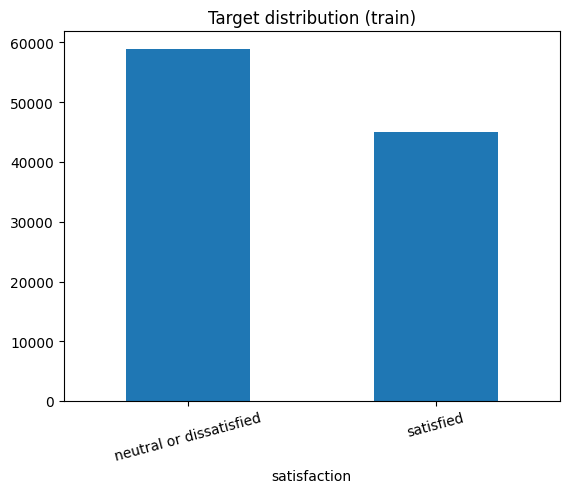

satisfaction
neutral or dissatisfied    0.566667
satisfied                  0.433333
Name: proportion, dtype: float64

In [7]:
# 1.2) Target distribution
print("Target unique values:", train_df[TARGET_COL].unique())
target_map = {"neutral or dissatisfied": 0, "satisfied": 1}

fig = plt.figure()
train_df[TARGET_COL].value_counts().plot(kind="bar")
plt.title("Target distribution (train)")
plt.xticks(rotation=15)
plt.show()

display(train_df[TARGET_COL].value_counts(normalize=True).rename("proportion"))

## 1.3 Missing values (train/test)

In [8]:
# 1.3) Missing values (train/test)
missing_train = train_df.isna().sum().sort_values(ascending=False)
missing_test  = test_df.isna().sum().sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_train": missing_train,
    "missing_test": missing_test
})
missing_summary["missing_rate_train"] = missing_summary["missing_train"] / len(train_df)
missing_summary["missing_rate_test"]  = missing_summary["missing_test"] / len(test_df)

display(missing_summary[(missing_summary["missing_train"] + missing_summary["missing_test"]) > 0])

,missing_train,missing_test,missing_rate_train,missing_rate_test
Arrival Delay in Minutes,310,83,0.002984,0.003195


## 1.4 Categorical vs Numeric + split X/y

In [9]:
# 1.4) Categorical vs Numeric + split X/y
drop_cols = [c for c in DROP_COLS_CANDIDATES if c in train_df.columns]
print("Drop cols:", drop_cols)

X_full = train_df.drop(columns=[TARGET_COL] + drop_cols)
y_full = train_df[TARGET_COL].map(target_map)

X_test = test_df.drop(columns=[TARGET_COL] + drop_cols)
y_test = test_df[TARGET_COL].map(target_map)

cat_cols = X_full.select_dtypes(include=["object"]).columns.tolist()
num_cols = [c for c in X_full.columns if c not in cat_cols]

print("Categorical cols:", cat_cols)
print("Numeric cols:", num_cols[:10], "... total:", len(num_cols))

Drop cols: ['Unnamed: 0', 'id']
Categorical cols: ['Gender', 'Customer Type', 'Type of Travel', 'Class']
Numeric cols: ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment'] ... total: 18


## 1.5 Insight nhanh: tỉ lệ satisfied theo nhóm categorical

In [10]:
# 1.5) Insight nhanh: tỉ lệ satisfied theo nhóm categorical
for c in cat_cols:
    print("\n===", c, "===")
    display(train_df[c].value_counts())
    display(pd.crosstab(train_df[c], train_df[TARGET_COL], normalize="index").round(3))


=== Gender ===


Gender
Female    52727
Male      51177
Name: count, dtype: int64

satisfaction,neutral or dissatisfied,satisfied
Gender,,
Female,0.573,0.427
Male,0.561,0.439



=== Customer Type ===


Customer Type
Loyal Customer       84923
disloyal Customer    18981
Name: count, dtype: int64

...

Type of Travel
Business travel    71655
Personal Travel    32249
Name: count, dtype: int64

satisfaction,neutral or dissatisfied,satisfied
Type of Travel,,
Business travel,0.417,0.583
Personal Travel,0.898,0.102



=== Class ===


Class
Business    49665
Eco         46745
Eco Plus     7494
Name: count, dtype: int64

satisfaction,neutral or dissatisfied,satisfied
Class,,
Business,0.306,0.694
Eco,0.814,0.186
Eco Plus,0.754,0.246


## 1.6 Histogram vài cột số

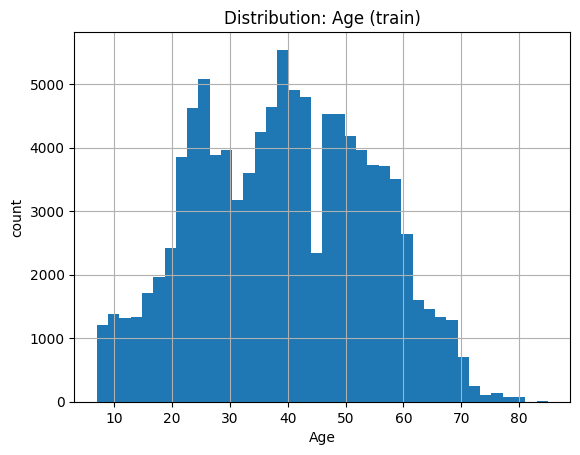

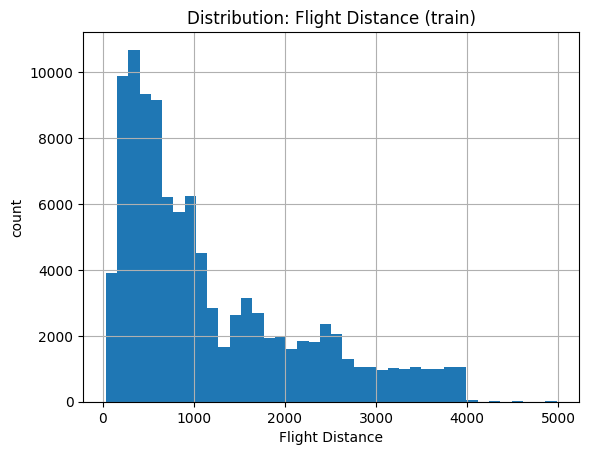

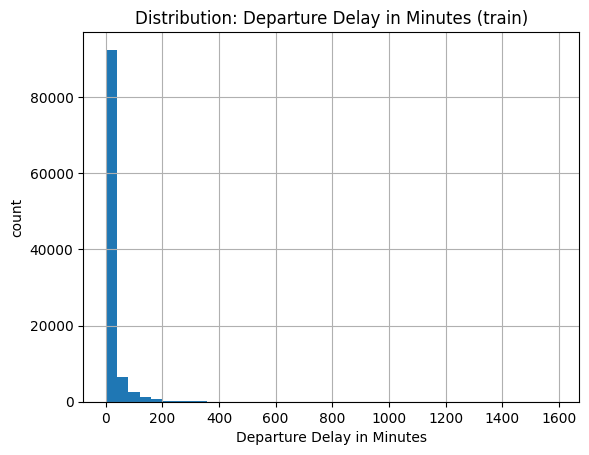

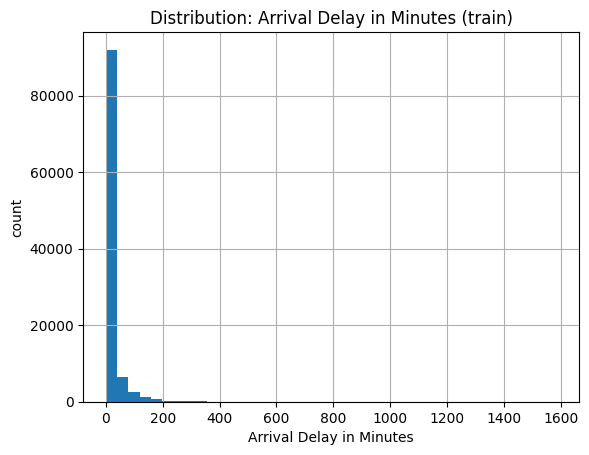

In [11]:
# 1.6) Histogram vài cột số
num_to_plot = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
num_to_plot = [c for c in num_to_plot if c in train_df.columns]

for c in num_to_plot:
    fig = plt.figure()
    train_df[c].hist(bins=40)
    plt.title(f"Distribution: {c} (train)")
    plt.xlabel(c)
    plt.ylabel("count")
    plt.show()

## 1.7 Correlation numeric vs target

,corr_with_target
target_bin,1.000000
Online boarding,0.503557
Inflight entertainment,0.398059
Seat comfort,0.349459
On-board service,0.322383
Leg room service,0.313131
Cleanliness,0.305198
Flight Distance,0.298780
Inflight wifi service,0.284245
Baggage handling,0.247749


,corr_with_target
Cleanliness,0.305198
Flight Distance,0.298780
Inflight wifi service,0.284245
Baggage handling,0.247749
Inflight service,0.244741
Checkin service,0.236174
Food and drink,0.209936
Ease of Online booking,0.171705
Age,0.137167
id,0.013734


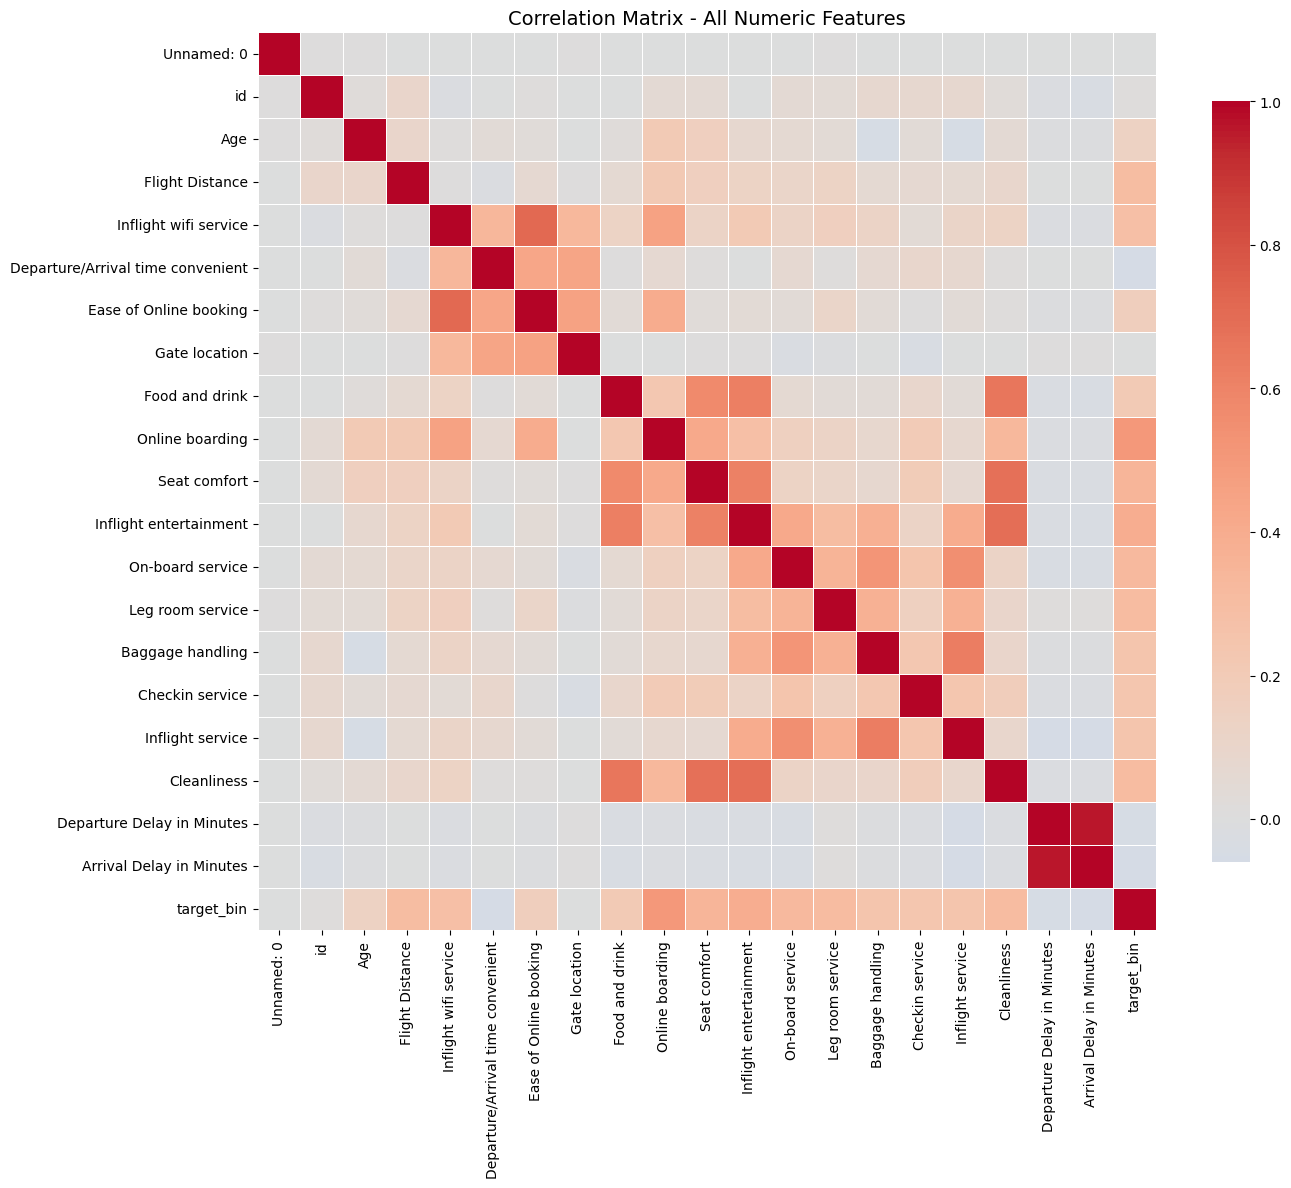

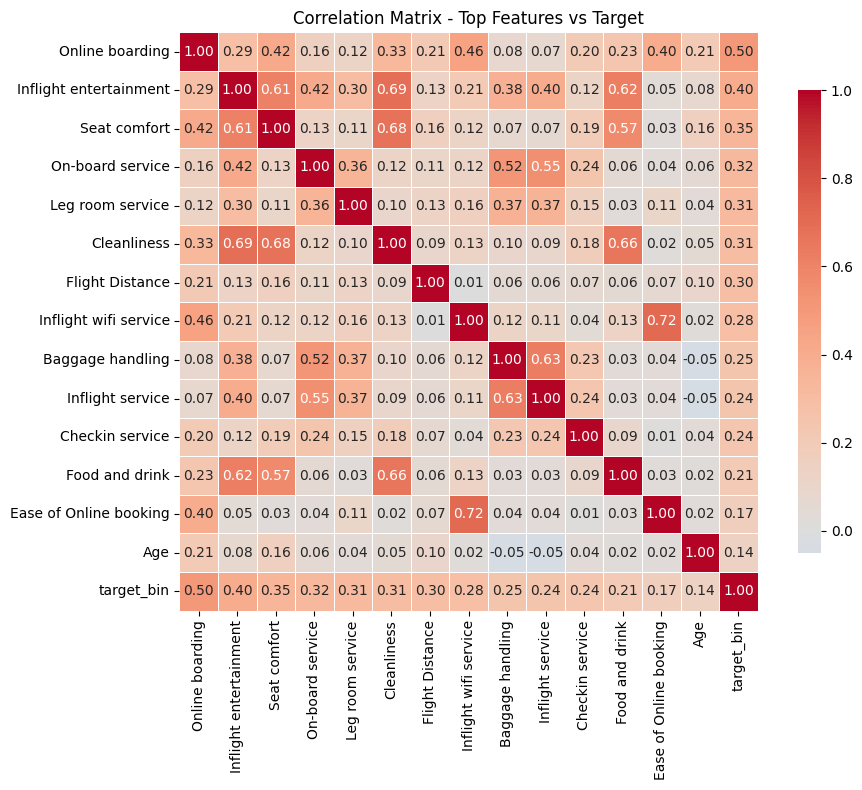

In [12]:
# 1.7) Correlation numeric vs target
import seaborn as sns

tmp = train_df.copy()
tmp["target_bin"] = tmp[TARGET_COL].map(target_map)

# Correlation với target
corr = tmp.drop(columns=[TARGET_COL]).corr(numeric_only=True)["target_bin"].sort_values(ascending=False)
display(corr.head(15).to_frame("corr_with_target"))
display(corr.tail(15).to_frame("corr_with_target"))

# Correlation matrix heatmap
corr_matrix = tmp.drop(columns=[TARGET_COL]).select_dtypes(include=[np.number]).corr()

# Plot full correlation matrix
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
plt.title("Correlation Matrix - All Numeric Features", fontsize=14)
plt.tight_layout()
plt.show()

# Plot top features correlated với target
top_features = corr.head(15).index.tolist()
if "target_bin" in top_features:
    top_features.remove("target_bin")
else:
    top_features = top_features[:14]

top_corr_matrix = tmp[top_features + ["target_bin"]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(top_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
plt.title("Correlation Matrix - Top Features vs Target", fontsize=12)
plt.tight_layout()
plt.show()


## 1.8 Boxplot (numeric) để kiểm tra outliers


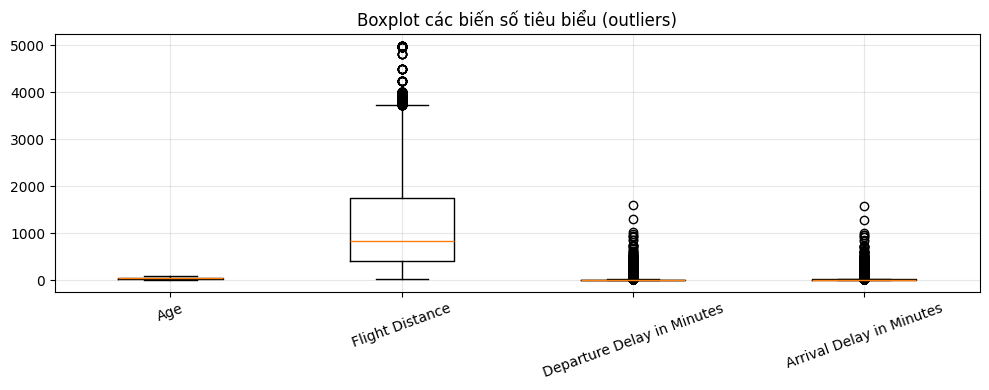

In [13]:

# 1.8) Boxplot một vài cột số (outliers)
import matplotlib.pyplot as plt

num_cols_focus = [c for c in ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"] if c in X_full.columns]
if len(num_cols_focus) == 0:
    print("Không tìm thấy các cột số tiêu biểu để vẽ boxplot.")
else:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.boxplot([X_full[c].dropna().values for c in num_cols_focus], labels=num_cols_focus, showfliers=True)
    ax.set_title("Boxplot các biến số tiêu biểu (outliers)")
    ax.tick_params(axis="x", rotation=20)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 1.9 Mutual Information (MI) để xem đặc trưng nào liên quan đến nhãn


,MI_score
num__Online boarding,0.214510
num__Inflight wifi service,0.164366
cat__Class_Business,0.132200
cat__Type of Travel_Business travel,0.111707
cat__Type of Travel_Personal Travel,0.111707
cat__Class_Eco,0.105890
num__Inflight entertainment,0.094858
num__Seat comfort,0.082094
num__Leg room service,0.061587
num__Flight Distance,0.058499


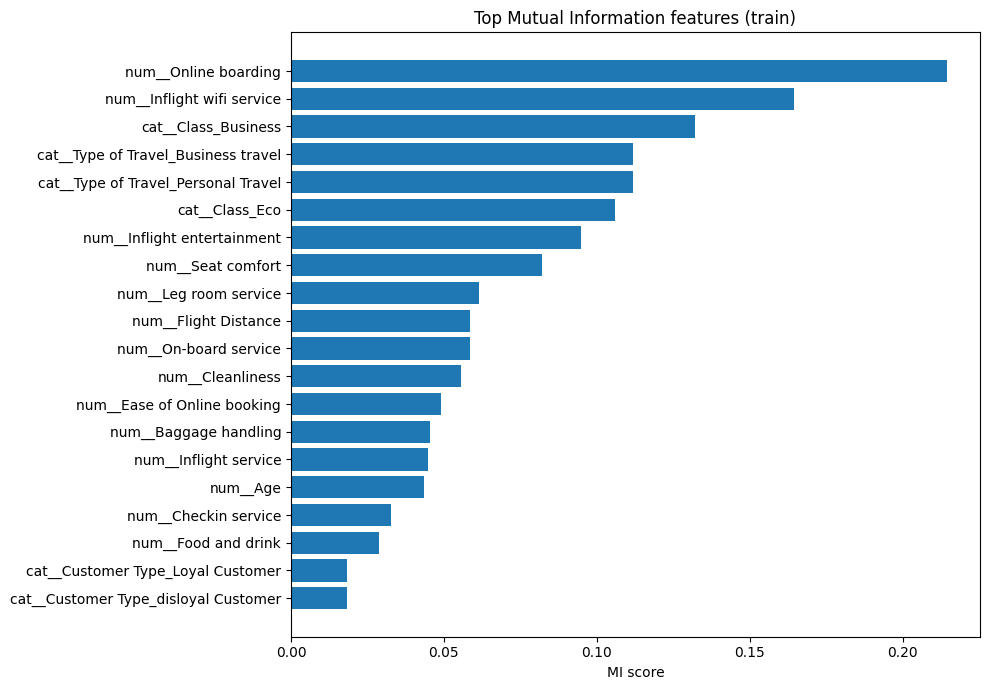

In [14]:

# 1.9) Mutual Information (MI) trên dữ liệu đã one-hot (EDA)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif

# Subsample để chạy nhanh hơn (MI khá nặng với 100k+ rows)
mi_sample_n = 30000 if FAST_MODE else 60000
if len(X_full) > mi_sample_n:
    X_mi_df = X_full.sample(mi_sample_n, random_state=RANDOM_STATE)
    y_mi = y_full.loc[X_mi_df.index]
else:
    X_mi_df = X_full
    y_mi = y_full

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

pre_for_mi = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
], remainder="drop", sparse_threshold=0.3)

X_mi = pre_for_mi.fit_transform(X_mi_df, y_mi)

feat_names = pre_for_mi.get_feature_names_out()

# heuristic: one-hot là discrete
is_discrete = np.array([name.startswith("cat__") for name in feat_names], dtype=bool)

mi = mutual_info_classif(X_mi, y_mi, discrete_features=is_discrete, random_state=RANDOM_STATE)
mi_s = pd.Series(mi, index=feat_names).sort_values(ascending=False)

display(mi_s.head(20).to_frame("MI_score"))

# plot top 20
topN = 20
mi_top = mi_s.head(topN).iloc[::-1]
plt.figure(figsize=(10, max(6, 0.35*topN)))
plt.barh(mi_top.index, mi_top.values)
plt.title("Top Mutual Information features (train)")
plt.xlabel("MI score")
plt.tight_layout()
plt.show()


# 2. Traditional ML

## 2.1 Preprocess + Pipeline

In [15]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import TruncatedSVD

class SafeTruncatedSVD(BaseEstimator, TransformerMixin):
    """TruncatedSVD an toàn: tự động giới hạn n_components <= n_features."""
    def __init__(self, n_components=32, random_state=42):
        self.n_components = n_components
        self.random_state = random_state

    def fit(self, X, y=None):
        n_features = X.shape[1]
        n_comp = int(min(self.n_components, n_features))
        if n_comp < 1:
            raise ValueError(f"Không thể SVD vì n_features={n_features}")
        self.n_components_ = n_comp
        self.svd_ = TruncatedSVD(n_components=self.n_components_, random_state=self.random_state)
        self.svd_.fit(X, y)
        return self

    def transform(self, X):
        return self.svd_.transform(X)

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

def build_preprocessor(scaler: str | None = "standard") -> ColumnTransformer:
    if scaler in (None, "none"):
        scaler_obj = "passthrough"
    elif scaler == "standard":
        scaler_obj = StandardScaler()
    elif scaler == "minmax":
        scaler_obj = MinMaxScaler()
    else:
        raise ValueError("scaler must be one of: standard, minmax, none")

    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", scaler_obj),
    ])

    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    pre = ColumnTransformer([
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ], remainder="drop", sparse_threshold=0.3)

    return pre

def make_pipeline(model, scaler="standard", use_svd=False, n_components=32):
    steps = [("preprocess", build_preprocessor(scaler=scaler))]
    if use_svd:
        steps.append(("svd", SafeTruncatedSVD(n_components=n_components, random_state=RANDOM_STATE)))
    steps.append(("model", model))
    return Pipeline(steps)

## 2.2 Baseline + Model Zoo (CV) + Log chọn/loại

**Cross-validation (StratifiedKFold).**  
Mình dùng *StratifiedKFold* để đảm bảo **tỷ lệ nhãn ở mỗi fold gần giống nhau**, đặc biệt quan trọng khi dữ liệu có thể **mất cân bằng lớp**. Cách này giúp điểm số ổn định và công bằng hơn so với KFold thường.

**Số fold (3 vs 5).**
- Khi chạy bình thường (không FAST_MODE): dùng **5-fold** để ước lượng tổng quát hóa **ổn định hơn** (giảm “hên xui” theo cách chia dữ liệu).
- Khi cần chạy nhanh (FAST_MODE): dùng **3-fold** để giảm thời gian (ít lần huấn luyện hơn), phù hợp giai đoạn thử nghiệm/iterate.

**Thước đo (metrics).**
- **Accuracy**: dễ hiểu nhưng có thể “đẹp giả” nếu dữ liệu lệch lớp.
- **F1-score**: cân bằng Precision/Recall cho lớp dương (mặc định `pos_label=1`), hữu ích khi quan tâm phát hiện đúng lớp quan trọng.
- **ROC-AUC**: đo chất lượng *xếp hạng* (ranking) dựa trên xác suất/điểm dự đoán, ít phụ thuộc ngưỡng.

### 2.2.1 Baseline

In [16]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
import numpy as np

def cv_summary(pipe, X, y, cv, scoring):
    res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    out = {}
    for k in scoring.keys():
        out[f"{k}_mean"] = float(np.mean(res[f"test_{k}"]))
        out[f"{k}_std"]  = float(np.std(res[f"test_{k}"]))
    return out

# CV folds
n_splits = 3 if FAST_MODE else 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

scoring = {"acc": "accuracy", "f1": "f1", "roc_auc": "roc_auc"}

# 2.2.1) Baseline
baseline_pipe = make_pipeline(DummyClassifier(strategy="most_frequent"), scaler="none", use_svd=False)
print(f"Running baseline CV ({n_splits} folds) on FULL train...")
baseline_stats = cv_summary(baseline_pipe, X_full, y_full, cv=cv, scoring=scoring)
baseline_stats

Running baseline CV (5 folds) on FULL train...


{'acc_mean': 0.5666673081240133,
 'acc_std': 8.341261236699538e-06,
 'f1_mean': 0.0,
 'f1_std': 0.0,
 'roc_auc_mean': 0.5,
 'roc_auc_std': 0.0}

**Vì sao cần baseline?**  
Baseline là “mốc sàn” để biết mô hình học máy **có thật sự học được gì** hay chỉ ăn may. Ở đây dùng:
- `DummyClassifier(strategy="most_frequent")`: luôn dự đoán **lớp xuất hiện nhiều nhất**.
- Đây là baseline mạnh nhất trong nhóm “ngây thơ” (naive) vì nó tối đa hóa accuracy trong các cách dự đoán hằng số.

**Kết quả baseline (CV trên FULL train):**
- `acc_mean ≈ 0.5667`: mô hình đoán **toàn lớp đa số**, nên accuracy xấp xỉ **tỷ lệ lớp đa số** trong dữ liệu (~56.67%).
- `f1_mean = 0.0`: do mô hình **không bao giờ dự đoán lớp 1** (mặc định F1 tính cho lớp 1), nên Precision/Recall cho lớp 1 đều bằng 0 ⇒ F1 = 0.
- `roc_auc_mean = 0.5`: tương đương **đoán ngẫu nhiên** về mặt ranking (không có khả năng phân biệt hai lớp).

**Ý nghĩa:**  
Nếu các mô hình “xịn” không vượt baseline một cách rõ rệt (đặc biệt ở F1 và ROC-AUC) thì pipeline chưa học được tín hiệu thực sự.

### 2.2.2 Model Zoo (CV)

Mình chọn một tập mô hình đa dạng để bao phủ nhiều “giả định học” khác nhau:

- **Logistic Regression (LogReg)**: mô hình tuyến tính, baseline mạnh cho dữ liệu đặc trưng nhiều chiều; nhanh, dễ giải thích.
- **LinearSVC (calibrated)**: biên phân tách tuyến tính tốt; bản *calibrated* giúp có xác suất/điểm phù hợp để tính ROC-AUC và so sánh công bằng.
- **KNN**: mô hình dựa trên láng giềng, nhạy với khoảng cách; thường hiệu quả khi biểu diễn đặc trưng “tốt” và số chiều không quá cao.
- **RandomForest / ExtraTrees**: ensemble cây quyết định, bắt quan hệ phi tuyến tốt, khá robust; ExtraTrees ngẫu nhiên hơn nên đôi khi tổng quát hóa tốt.
- **HistGradientBoosting**: boosting hiệu quả cho dữ liệu tabular, thường đạt chất lượng rất cao; học phi tuyến mạnh và tối ưu tốt.

Mục tiêu là không “đánh bạc” với 1 họ mô hình, mà **so sánh công bằng nhiều họ** rồi chọn theo CV.

**Standardization (chuẩn hóa).**  
Các mô hình dựa trên khoảng cách/biên như **LogReg, SVM, KNN** nhạy với thang đo đặc trưng. Chuẩn hóa giúp:
- hội tụ ổn định hơn,
- tránh đặc trưng có biên độ lớn “lấn át” đặc trưng khác.

**SVD (giảm chiều, ví dụ SVD(32)).**  
SVD thường hữu ích khi:
- số chiều lớn (đặc biệt đặc trưng dạng sparse/one-hot/TF-IDF),
- có nhiễu/đồng tuyến tính,
- muốn tăng tốc và giảm “lời nguyền số chiều”.

Đặc biệt với **KNN**, giảm chiều giúp khoảng cách có ý nghĩa hơn và giảm chi phí tính khoảng cách.  
Với **mô hình cây (RF/ExtraTrees/HGB)**, giảm chiều thường **không cần thiết** vì cây tự chọn ngưỡng và tương tác đặc trưng theo cách khác (không dựa trên chuẩn hóa/khoảng cách).

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# 2.2.2) Model zoo (FULL CV)
models_fullcv = {}

models_fullcv["LogReg (std)"] = make_pipeline(LogisticRegression(max_iter=3000), scaler="standard")
models_fullcv["LinearSVC calibrated (std)"] = make_pipeline(
    CalibratedClassifierCV(LinearSVC(), method="sigmoid", cv=3),
    scaler="standard",
)
models_fullcv["RandomForest"] = make_pipeline(
    RandomForestClassifier(n_estimators=300 if not FAST_MODE else 200, random_state=RANDOM_STATE, n_jobs=-1),
    scaler="none",
)
models_fullcv["ExtraTrees"] = make_pipeline(
    ExtraTreesClassifier(n_estimators=600 if not FAST_MODE else 300, random_state=RANDOM_STATE, n_jobs=-1),
    scaler="none",
)
models_fullcv["HistGradientBoosting"] = make_pipeline(
    HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    scaler="none",
)
models_fullcv["LogReg + SVD(32)"] = make_pipeline(
    LogisticRegression(max_iter=3000),
    scaler="standard",
    use_svd=True,
    n_components=32
)

models_fullcv["KNN(k=15)+SVD(32)"] = make_pipeline(
    KNeighborsClassifier(n_neighbors=15, weights="distance", n_jobs=-1),
    scaler="standard",
    use_svd=True,
    n_components=32
)

# FAST_MODE: giảm bớt model nếu muốn
if FAST_MODE:
    keep = ["LogReg (std)", "RandomForest", "HistGradientBoosting", "KNN(k=15)+SVD(32)"]
    models_fullcv = {k: models_fullcv[k] for k in keep}

print("Evaluating", len(models_fullcv), "models with", n_splits, "fold CV on FULL train...")

rows = []
for name, pipe in models_fullcv.items():
    stats = cv_summary(pipe, X_full, y_full, cv=cv, scoring=scoring)
    rows.append({
        "model": name,
        "eval_data": "full_train",
        "n_samples": int(len(X_full)),
        "cv_folds": int(n_splits),
        **stats
    })

zoo_df = pd.DataFrame(rows).sort_values("f1_mean", ascending=False).reset_index(drop=True)
display(zoo_df)

Evaluating 7 models with 5 fold CV on FULL train...


,model,eval_data,n_samples,cv_folds,acc_mean,acc_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,HistGradientBoosting,full_train,103904,5,0.963399,0.000889,0.957006,0.001091,0.994861,0.000366
1,RandomForest,full_train,103904,5,0.962966,0.001140,0.956551,0.001378,0.994232,0.000404
2,ExtraTrees,full_train,103904,5,0.960820,0.001578,0.954086,0.001913,0.993463,0.000457
3,KNN(k=15)+SVD(32),full_train,103904,5,0.928001,0.001619,0.913720,0.002071,0.979416,0.001243
4,LogReg (std),full_train,103904,5,0.875212,0.002185,0.853086,0.002540,0.926676,0.001891
5,LogReg + SVD(32),full_train,103904,5,0.875212,0.002185,0.853086,0.002540,0.926676,0.001891
6,LinearSVC calibrated (std),full_train,103904,5,0.874115,0.002563,0.851853,0.003051,0.926117,0.001955


### 2.2.3 Model selection log

In [18]:
# 2.2.3) Model selection log (rõ đã thử bao nhiêu model + lý do chọn/loại)
baseline_f1  = baseline_stats["f1_mean"]
baseline_auc = baseline_stats["roc_auc_mean"]

log_df = zoo_df.copy()
log_df["f1_gain_vs_baseline"]  = log_df["f1_mean"] - baseline_f1
log_df["auc_gain_vs_baseline"] = log_df["roc_auc_mean"] - baseline_auc

# Chỉ chọn best từ nhóm full_train (điều kiện đánh giá công bằng)
full = log_df[log_df["eval_data"] == "full_train"].copy()
full = full.sort_values(["f1_mean", "roc_auc_mean"], ascending=False).reset_index(drop=True)
full["rank_fullcv"] = np.arange(1, len(full) + 1)

best_name = full.loc[0, "model"]
best_f1 = float(full.loc[0, "f1_mean"])
best_auc = float(full.loc[0, "roc_auc_mean"])

log_df["decision"] = "rejected"
log_df.loc[log_df["model"] == best_name, "decision"] = "SELECTED (best full CV)"

display(log_df.sort_values(["eval_data", "decision", "f1_mean"], ascending=[True, False, False]).reset_index(drop=True))
print("Selected model:", best_name)
print("Tổng số model đã thử:", len(log_df))
print("Top 3 full CV:")
display(full[["rank_fullcv", "model", "f1_mean", "roc_auc_mean", "f1_std"]].head(3))


,model,eval_data,n_samples,cv_folds,acc_mean,acc_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,f1_gain_vs_baseline,auc_gain_vs_baseline,decision
0,RandomForest,full_train,103904,5,0.962966,0.001140,0.956551,0.001378,0.994232,0.000404,0.956551,0.494232,rejected
1,ExtraTrees,full_train,103904,5,0.960820,0.001578,0.954086,0.001913,0.993463,0.000457,0.954086,0.493463,rejected
2,KNN(k=15)+SVD(32),full_train,103904,5,0.928001,0.001619,0.913720,0.002071,0.979416,0.001243,0.913720,0.479416,rejected
3,LogReg (std),full_train,103904,5,0.875212,0.002185,0.853086,0.002540,0.926676,0.001891,0.853086,0.426676,rejected
4,LogReg + SVD(32),full_train,103904,5,0.875212,0.002185,0.853086,0.002540,0.926676,0.001891,0.853086,0.426676,rejected
5,LinearSVC calibrated (std),full_train,103904,5,0.874115,0.002563,0.851853,0.003051,0.926117,0.001955,0.851853,0.426117,rejected
6,HistGradientBoosting,full_train,103904,5,0.963399,0.000889,0.957006,0.001091,0.994861,0.000366,0.957006,0.494861,SELECTED (best full CV)


Selected model: HistGradientBoosting
Tổng số model đã thử: 7
Top 3 full CV:


,rank_fullcv,model,f1_mean,roc_auc_mean,f1_std
0,1,HistGradientBoosting,0.957006,0.994861,0.001091
1,2,RandomForest,0.956551,0.994232,0.001378
2,3,ExtraTrees,0.954086,0.993463,0.001913


## 2.3 Tuning model được chọn

In [19]:
from sklearn.model_selection import RandomizedSearchCV

selected_pipe = models_fullcv[best_name]
param_distributions = {}

if "LogReg" in best_name:
    param_distributions = {"model__C": np.logspace(-3, 2, 20), "model__penalty": ["l2"]}
elif "RandomForest" in best_name:
    param_distributions = {
        "model__n_estimators": [200, 400, 600],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None],
    }
elif "ExtraTrees" in best_name:
    param_distributions = {
        "model__n_estimators": [300, 600, 900],
        "model__max_depth": [None, 10, 20, 30],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None],
    }
elif "HistGradientBoosting" in best_name:
    param_distributions = {
        "model__learning_rate": [0.02, 0.05, 0.1, 0.2],
        "model__max_depth": [None, 3, 5, 7],
        "model__max_leaf_nodes": [15, 31, 63],
        "model__min_samples_leaf": [20, 50, 100],
    }
elif "SVC" in best_name:
    param_distributions = {"model__base_estimator__C": np.logspace(-3, 2, 15)}

do_tuning = not FAST_MODE
print("Tuning enabled:", do_tuning)

if do_tuning and len(param_distributions) > 0:
    cv_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    n_iter = 25 if not FAST_MODE else 10

    search = RandomizedSearchCV(
        selected_pipe,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring="f1",
        cv=cv_tune,
        n_jobs=-1,
        verbose=1,
        random_state=RANDOM_STATE
    )
    search.fit(X_full, y_full)
    print("Best params:", search.best_params_)
    print("Best CV F1:", search.best_score_)
    tuned_pipe = search.best_estimator_
else:
    tuned_pipe = selected_pipe
    print("Skip tuning.")

Tuning enabled: True
Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'model__min_samples_leaf': 20, 'model__max_leaf_nodes': 63, 'model__max_depth': None, 'model__learning_rate': 0.1}
Best CV F1: 0.958611870187856


## 2.4 Final: train full → evaluate test

Test metrics:
  Accuracy : 0.9644287034185401
  Precision: 0.9754968690443779
  Recall   : 0.9426466719284399
  F1       : 0.9587904736419588
  ROC-AUC  : 0.9955515606325606

Classification report:
              precision    recall  f1-score   support

           0     0.9563    0.9815    0.9687     14573
           1     0.9755    0.9426    0.9588     11403

    accuracy                         0.9644     25976
   macro avg     0.9659    0.9621    0.9638     25976
weighted avg     0.9647    0.9644    0.9644     25976



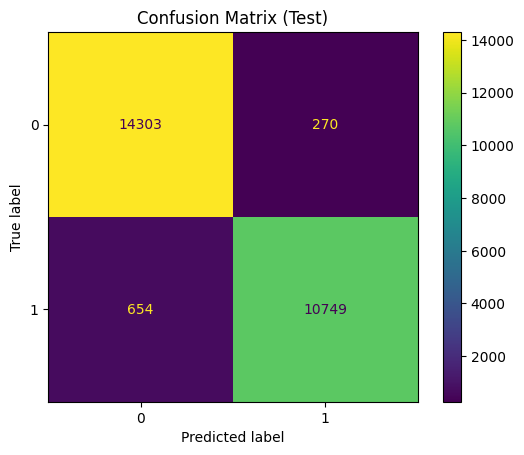

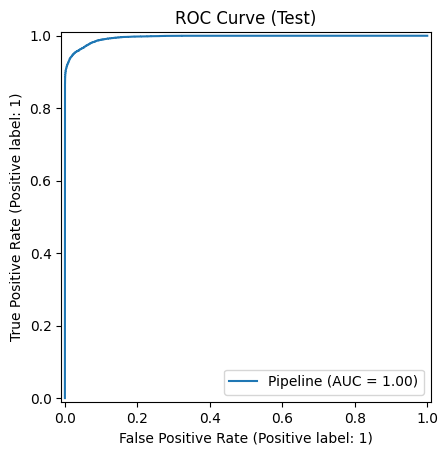

In [20]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

tuned_pipe.fit(X_full, y_full)
test_pred = tuned_pipe.predict(X_test)

print("Test metrics:")
print("  Accuracy :", accuracy_score(y_test, test_pred))
print("  Precision:", precision_score(y_test, test_pred))
print("  Recall   :", recall_score(y_test, test_pred))
print("  F1       :", f1_score(y_test, test_pred))

roc_auc = None
if hasattr(tuned_pipe, "predict_proba"):
    test_proba = tuned_pipe.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, test_proba)
elif hasattr(tuned_pipe, "decision_function"):
    test_score = tuned_pipe.decision_function(X_test)
    roc_auc = roc_auc_score(y_test, test_score)

if roc_auc is not None:
    print("  ROC-AUC  :", roc_auc)

print("\nClassification report:")
print(classification_report(y_test, test_pred, digits=4))

cm = confusion_matrix(y_test, test_pred)
ConfusionMatrixDisplay(cm).plot(values_format="d")
plt.title("Confusion Matrix (Test)")
plt.show()

try:
    RocCurveDisplay.from_estimator(tuned_pipe, X_test, y_test)
    plt.title("ROC Curve (Test)")
    plt.show()
except Exception as e:
    print("Không vẽ được ROC curve:", e)

## 2.5 Save outputs (theo OUT_DIR)

In [21]:
import joblib
from scipy import sparse

# 2.5.1) Save model pipeline
model_path = ARTIFACTS_DIR / "best_pipeline.joblib"
joblib.dump(tuned_pipe, model_path)
print("Saved:", model_path)

# 2.5.2) Save EDA / selection tables
missing_summary.to_csv(EDA_DIR / "missing_summary.csv")
zoo_df.to_csv(EDA_DIR / "model_zoo_results.csv", index=False)
log_df.to_csv(EDA_DIR / "model_selection_log.csv", index=False)
print("Saved:", EDA_DIR / "missing_summary.csv")
print("Saved:", EDA_DIR / "model_zoo_results.csv")
print("Saved:", EDA_DIR / "model_selection_log.csv")

# 2.5.3) Save transformed features (sparse → npz, dense → npy)
pre = tuned_pipe.named_steps["preprocess"]
Xtr_feat = pre.transform(X_full)
Xte_feat = pre.transform(X_test)

if sparse.issparse(Xtr_feat):
    sparse.save_npz(FEATURES_DIR / "train_features.npz", Xtr_feat)
    sparse.save_npz(FEATURES_DIR / "test_features.npz", Xte_feat)
    print("Saved:", FEATURES_DIR / "train_features.npz")
    print("Saved:", FEATURES_DIR / "test_features.npz")
else:
    np.save(FEATURES_DIR / "train_features.npy", Xtr_feat)
    np.save(FEATURES_DIR / "test_features.npy", Xte_feat)
    print("Saved:", FEATURES_DIR / "train_features.npy")
    print("Saved:", FEATURES_DIR / "test_features.npy")

# 2.5.4) Feature names (nếu có)
feature_names = None
try:
    feature_names = pre.get_feature_names_out().tolist()
except Exception:
    feature_names = None

with open(FEATURES_DIR / "feature_names.json", "w", encoding="utf-8") as f:
    json.dump(feature_names, f, ensure_ascii=False, indent=2)

print("Saved:", FEATURES_DIR / "feature_names.json")

Saved: /root/test/score/src/outputs/artifacts/best_pipeline.joblib
Saved: /root/test/score/src/outputs/eda_outputs/missing_summary.csv
Saved: /root/test/score/src/outputs/eda_outputs/model_zoo_results.csv
Saved: /root/test/score/src/outputs/eda_outputs/model_selection_log.csv
Saved: /root/test/score/src/outputs/features/train_features.npy
Saved: /root/test/score/src/outputs/features/test_features.npy
Saved: /root/test/score/src/outputs/features/feature_names.json


# 3. Deep Learning (Tabular Neural Networks)

## 3.0 Setup (PyTorch + utils)

Phần này thử **nhiều kiến trúc Deep Learning cho dữ liệu bảng** để chứng minh có *research + test* (không chọn cứng 1 model).  
Mỗi model được tách riêng thành từng mục con, sau đó có bảng so sánh + decision log.

In [22]:

# 3.0) Setup
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def seed_torch(seed: int = 42):
    import random, os
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_torch(RANDOM_STATE)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# Hyperparams (tự giảm nếu FAST_MODE)
DL_SVD_COMPONENTS = 64 if FAST_MODE else 128
DL_BATCH = 2048 if FAST_MODE else 1024
DL_EPOCHS = 8 if FAST_MODE else 25
DL_PATIENCE = 3 if FAST_MODE else 6
DL_LR = 1e-3
DL_WD = 1e-5


DEVICE: cuda


## 3.1 DL feature pipeline (OneHot → SVD → Scaling)

Ta dùng **cùng nguồn dữ liệu** `X_full/y_full` và `X_test/y_test` như phần Traditional để so sánh công bằng. Vì One-Hot tạo ma trận rất lớn, ta nén xuống vector dense bằng **TruncatedSVD** rồi mới đưa vào MLP.

In [23]:
# 3.1) Build DL feature pipeline + split train/val  (FIXED: auto-clamp SVD components)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import TruncatedSVD
import scipy.sparse as sp

# Nếu bạn chạy riêng từ Section 3 (không run các cell trên), sẽ cần load data + tạo X_full/y_full trước.
# Notebook hiện đã tạo X_full/y_full ở Section 1.4, nên đoạn này chỉ dùng lại.

X_tr_df, X_val_df, y_tr, y_val = train_test_split(
    X_full, y_full,
    test_size=0.2,
    stratify=y_full,
    random_state=RANDOM_STATE
)

dl_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

# ---- FIX: clamp SVD components to <= n_features after preprocess ----
Xt_tmp = dl_preprocess.fit_transform(X_tr_df, y_tr)
n_features_after_preprocess = Xt_tmp.shape[1]
print("DL preprocess n_features:", n_features_after_preprocess)

use_svd = True
if DL_SVD_COMPONENTS is None:
    use_svd = False

# clamp
if use_svd:
    svd_k = int(min(DL_SVD_COMPONENTS, n_features_after_preprocess))
    # nếu svd_k >= n_features => không giảm chiều, bỏ qua để tránh tốn thời gian
    if svd_k >= n_features_after_preprocess:
        use_svd = False

svd_step = TruncatedSVD(n_components=svd_k, random_state=RANDOM_STATE) if use_svd else "passthrough"

# scaler: nếu dữ liệu vẫn sparse (không qua SVD) thì phải with_mean=False
scaler_step = StandardScaler(with_mean=False) if (svd_step == "passthrough" and sp.issparse(Xt_tmp)) else StandardScaler()

dl_feature_pipe = Pipeline([
    ("preprocess", dl_preprocess),
    ("svd", svd_step),
    ("scaler", scaler_step),
])

print("Fitting DL feature pipe... | use_svd:", use_svd, "| svd_k:", (svd_k if use_svd else None))
dl_feature_pipe.fit(X_tr_df, y_tr)

X_tr = dl_feature_pipe.transform(X_tr_df).astype(np.float32)
X_val = dl_feature_pipe.transform(X_val_df).astype(np.float32)
X_te  = dl_feature_pipe.transform(X_test).astype(np.float32)

y_tr_np = y_tr.to_numpy().astype(np.float32)
y_val_np = y_val.to_numpy().astype(np.float32)
y_te_np  = y_test.to_numpy().astype(np.float32)

INPUT_DIM = X_tr.shape[1]
print("DL INPUT_DIM:", INPUT_DIM, "| train/val/test:", X_tr.shape, X_val.shape, X_te.shape)

class TabDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).view(-1, 1)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(TabDataset(X_tr, y_tr_np), batch_size=DL_BATCH, shuffle=True, drop_last=False)
val_loader   = DataLoader(TabDataset(X_val, y_val_np), batch_size=DL_BATCH, shuffle=False, drop_last=False)
test_loader  = DataLoader(TabDataset(X_te,  y_te_np),  batch_size=DL_BATCH, shuffle=False, drop_last=False)

def eval_logits_to_metrics(y_true, logits):
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    out = {}
    out["acc"] = float(accuracy_score(y_true, preds))
    out["f1"]  = float(f1_score(y_true, preds))
    try:
        out["roc_auc"] = float(roc_auc_score(y_true, probs))
    except Exception:
        out["roc_auc"] = float("nan")
    return out

@torch.no_grad()
def predict_logits(model, loader, device=DEVICE):
    model.eval()
    all_logits = []
    all_y = []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb).detach().cpu().numpy().reshape(-1)
        all_logits.append(logits)
        all_y.append(yb.numpy().reshape(-1))
    return np.concatenate(all_y), np.concatenate(all_logits)

def train_model(model, train_loader, val_loader, epochs=DL_EPOCHS, lr=DL_LR, weight_decay=DL_WD, patience=DL_PATIENCE, device=DEVICE):
    model = model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_f1 = -1.0
    best_state = None
    bad = 0
    history = []

    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

        yv, lv = predict_logits(model, val_loader, device=device)
        m = eval_logits_to_metrics(yv.astype(int), lv)
        history.append({"epoch": ep, **m})

        if m["f1"] > best_f1 + 1e-6:
            best_f1 = m["f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1

        print(f"epoch {ep:02d} | val_acc={m['acc']:.4f} val_f1={m['f1']:.4f} val_auc={m['roc_auc']:.4f} | bad={bad}/{patience}")
        if bad >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


DL preprocess n_features: 27
Fitting DL feature pipe... | use_svd: False | svd_k: None
DL INPUT_DIM: 27 | train/val/test: (83123, 27) (20781, 27) (25976, 27)


## 3.2 Model A — MLP (baseline neural)

In [24]:

# 3.2) MLP
class MLP(nn.Module):
    def __init__(self, input_dim, hidden1=256, hidden2=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 1),
        )
    def forward(self, x):
        return self.net(x)

dl_results = {}      # lưu metrics val/test
dl_models  = {}      # lưu model đã train

mlp = MLP(INPUT_DIM)
mlp, _ = train_model(mlp, train_loader, val_loader)

# eval val + test
y_val_true, val_logits = predict_logits(mlp, val_loader)
y_te_true,  te_logits  = predict_logits(mlp, test_loader)

dl_results["MLP"] = {
    "val":  eval_logits_to_metrics(y_val_true.astype(int), val_logits),
    "test": eval_logits_to_metrics(y_te_true.astype(int), te_logits),
}
dl_models["MLP"] = mlp
dl_results["MLP"]


epoch 01 | val_acc=0.9150 val_f1=0.8993 val_auc=0.9701 | bad=0/6
epoch 02 | val_acc=0.9342 val_f1=0.9220 val_auc=0.9829 | bad=0/6
epoch 03 | val_acc=0.9426 val_f1=0.9321 val_auc=0.9862 | bad=0/6
epoch 04 | val_acc=0.9399 val_f1=0.9318 val_auc=0.9884 | bad=1/6
epoch 05 | val_acc=0.9457 val_f1=0.9371 val_auc=0.9895 | bad=0/6
epoch 06 | val_acc=0.9503 val_f1=0.9412 val_auc=0.9906 | bad=0/6
epoch 07 | val_acc=0.9532 val_f1=0.9455 val_auc=0.9914 | bad=0/6
epoch 08 | val_acc=0.9459 val_f1=0.9385 val_auc=0.9917 | bad=1/6
epoch 09 | val_acc=0.9534 val_f1=0.9455 val_auc=0.9922 | bad=2/6
epoch 10 | val_acc=0.9564 val_f1=0.9491 val_auc=0.9927 | bad=0/6
epoch 11 | val_acc=0.9542 val_f1=0.9470 val_auc=0.9929 | bad=1/6
epoch 12 | val_acc=0.9529 val_f1=0.9452 val_auc=0.9926 | bad=2/6
epoch 13 | val_acc=0.9565 val_f1=0.9487 val_auc=0.9927 | bad=3/6
epoch 14 | val_acc=0.9546 val_f1=0.9475 val_auc=0.9930 | bad=4/6
epoch 15 | val_acc=0.9567 val_f1=0.9491 val_auc=0.9930 | bad=0/6
epoch 16 | val_acc=0.9539

{'val': {'acc': 0.9595784610942688,
  'f1': 0.9527027027027027,
  'roc_auc': 0.9940061605267605},
 'test': {'acc': 0.9599245457345241,
  'f1': 0.953698349864342,
  'roc_auc': 0.9937670451517107}}

## 3.3 Model B — MLP + BatchNorm + Dropout

In [25]:

# 3.3) MLP + BN + Dropout
class MLP_BN_Dropout(nn.Module):
    def __init__(self, input_dim, hidden=256, dropout=0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x)

m2 = MLP_BN_Dropout(INPUT_DIM)
m2, _ = train_model(m2, train_loader, val_loader)

y_val_true, val_logits = predict_logits(m2, val_loader)
y_te_true,  te_logits  = predict_logits(m2, test_loader)

dl_results["MLP_BN_Dropout"] = {
    "val":  eval_logits_to_metrics(y_val_true.astype(int), val_logits),
    "test": eval_logits_to_metrics(y_te_true.astype(int), te_logits),
}
dl_models["MLP_BN_Dropout"] = m2
dl_results["MLP_BN_Dropout"]


epoch 01 | val_acc=0.9287 val_f1=0.9168 val_auc=0.9801 | bad=0/6
epoch 02 | val_acc=0.9378 val_f1=0.9269 val_auc=0.9856 | bad=0/6
epoch 03 | val_acc=0.9442 val_f1=0.9357 val_auc=0.9880 | bad=0/6
epoch 04 | val_acc=0.9496 val_f1=0.9417 val_auc=0.9899 | bad=0/6
epoch 05 | val_acc=0.9509 val_f1=0.9427 val_auc=0.9910 | bad=0/6
epoch 06 | val_acc=0.9549 val_f1=0.9473 val_auc=0.9920 | bad=0/6
epoch 07 | val_acc=0.9565 val_f1=0.9491 val_auc=0.9922 | bad=0/6
epoch 08 | val_acc=0.9557 val_f1=0.9484 val_auc=0.9926 | bad=1/6
epoch 09 | val_acc=0.9569 val_f1=0.9496 val_auc=0.9931 | bad=0/6
epoch 10 | val_acc=0.9575 val_f1=0.9502 val_auc=0.9934 | bad=0/6
epoch 11 | val_acc=0.9586 val_f1=0.9516 val_auc=0.9935 | bad=0/6
epoch 12 | val_acc=0.9580 val_f1=0.9511 val_auc=0.9937 | bad=1/6
epoch 13 | val_acc=0.9597 val_f1=0.9528 val_auc=0.9938 | bad=0/6
epoch 14 | val_acc=0.9586 val_f1=0.9518 val_auc=0.9940 | bad=1/6
epoch 15 | val_acc=0.9594 val_f1=0.9524 val_auc=0.9940 | bad=2/6
epoch 16 | val_acc=0.9596

{'val': {'acc': 0.9623694721139503,
  'f1': 0.9562395075545607,
  'roc_auc': 0.9946903648788114},
 'test': {'acc': 0.961079457961195,
  'f1': 0.9552437026871486,
  'roc_auc': 0.9945004065240043}}

## 3.4 Model C — ResMLP (Residual MLP)

In [26]:

# 3.4) ResMLP
class ResBlock(nn.Module):
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.act = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(dim, dim)
    def forward(self, x):
        h = self.fc2(self.drop(self.act(self.fc1(x))))
        return x + h

class ResMLP(nn.Module):
    def __init__(self, input_dim, hidden=256, n_blocks=3, dropout=0.2):
        super().__init__()
        self.inp = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
        )
        self.blocks = nn.Sequential(*[ResBlock(hidden, dropout=dropout) for _ in range(n_blocks)])
        self.out = nn.Linear(hidden, 1)

    def forward(self, x):
        x = self.inp(x)
        x = self.blocks(x)
        return self.out(x)

m3 = ResMLP(INPUT_DIM, hidden=256, n_blocks=3, dropout=0.2)
m3, _ = train_model(m3, train_loader, val_loader)

y_val_true, val_logits = predict_logits(m3, val_loader)
y_te_true,  te_logits  = predict_logits(m3, test_loader)

dl_results["ResMLP"] = {
    "val":  eval_logits_to_metrics(y_val_true.astype(int), val_logits),
    "test": eval_logits_to_metrics(y_te_true.astype(int), te_logits),
}
dl_models["ResMLP"] = m3
dl_results["ResMLP"]


epoch 01 | val_acc=0.9401 val_f1=0.9300 val_auc=0.9861 | bad=0/6
epoch 02 | val_acc=0.9416 val_f1=0.9340 val_auc=0.9907 | bad=0/6
epoch 03 | val_acc=0.9546 val_f1=0.9471 val_auc=0.9927 | bad=0/6
epoch 04 | val_acc=0.9571 val_f1=0.9501 val_auc=0.9932 | bad=0/6
epoch 05 | val_acc=0.9581 val_f1=0.9513 val_auc=0.9937 | bad=0/6
epoch 06 | val_acc=0.9583 val_f1=0.9517 val_auc=0.9939 | bad=0/6
epoch 07 | val_acc=0.9594 val_f1=0.9525 val_auc=0.9942 | bad=0/6
epoch 08 | val_acc=0.9598 val_f1=0.9532 val_auc=0.9941 | bad=0/6
epoch 09 | val_acc=0.9600 val_f1=0.9529 val_auc=0.9938 | bad=1/6
epoch 10 | val_acc=0.9609 val_f1=0.9547 val_auc=0.9942 | bad=0/6
epoch 11 | val_acc=0.9609 val_f1=0.9540 val_auc=0.9941 | bad=1/6
epoch 12 | val_acc=0.9572 val_f1=0.9504 val_auc=0.9939 | bad=2/6
epoch 13 | val_acc=0.9617 val_f1=0.9549 val_auc=0.9943 | bad=0/6
epoch 14 | val_acc=0.9620 val_f1=0.9557 val_auc=0.9940 | bad=0/6
epoch 15 | val_acc=0.9618 val_f1=0.9557 val_auc=0.9947 | bad=0/6
epoch 16 | val_acc=0.9626

{'val': {'acc': 0.963620614984842,
  'f1': 0.9574850972893938,
  'roc_auc': 0.9945757980168022},
 'test': {'acc': 0.9616569140745304,
  'f1': 0.955709711846318,
  'roc_auc': 0.9944183188179028}}

## 3.5 Model D — Wide & Deep

In [27]:

# 3.5) Wide & Deep
class WideDeep(nn.Module):
    def __init__(self, input_dim, deep_hidden=256, dropout=0.25):
        super().__init__()
        self.wide = nn.Linear(input_dim, 1)

        self.deep = nn.Sequential(
            nn.Linear(input_dim, deep_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(deep_hidden, deep_hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(deep_hidden // 2, 1),
        )

    def forward(self, x):
        return self.wide(x) + self.deep(x)

m4 = WideDeep(INPUT_DIM, deep_hidden=256, dropout=0.25)
m4, _ = train_model(m4, train_loader, val_loader)

y_val_true, val_logits = predict_logits(m4, val_loader)
y_te_true,  te_logits  = predict_logits(m4, test_loader)

dl_results["WideDeep"] = {
    "val":  eval_logits_to_metrics(y_val_true.astype(int), val_logits),
    "test": eval_logits_to_metrics(y_te_true.astype(int), te_logits),
}
dl_models["WideDeep"] = m4
dl_results["WideDeep"]


epoch 01 | val_acc=0.9107 val_f1=0.8943 val_auc=0.9617 | bad=0/6
epoch 02 | val_acc=0.9285 val_f1=0.9163 val_auc=0.9802 | bad=0/6
epoch 03 | val_acc=0.9355 val_f1=0.9247 val_auc=0.9845 | bad=0/6
epoch 04 | val_acc=0.9412 val_f1=0.9308 val_auc=0.9868 | bad=0/6
epoch 05 | val_acc=0.9441 val_f1=0.9353 val_auc=0.9883 | bad=0/6
epoch 06 | val_acc=0.9497 val_f1=0.9412 val_auc=0.9891 | bad=0/6
epoch 07 | val_acc=0.9504 val_f1=0.9418 val_auc=0.9903 | bad=0/6
epoch 08 | val_acc=0.9460 val_f1=0.9381 val_auc=0.9905 | bad=1/6
epoch 09 | val_acc=0.9525 val_f1=0.9446 val_auc=0.9914 | bad=0/6
epoch 10 | val_acc=0.9546 val_f1=0.9470 val_auc=0.9920 | bad=0/6
epoch 11 | val_acc=0.9543 val_f1=0.9466 val_auc=0.9923 | bad=1/6
epoch 12 | val_acc=0.9564 val_f1=0.9489 val_auc=0.9928 | bad=0/6
epoch 13 | val_acc=0.9562 val_f1=0.9488 val_auc=0.9930 | bad=1/6
epoch 14 | val_acc=0.9567 val_f1=0.9491 val_auc=0.9933 | bad=0/6
epoch 15 | val_acc=0.9563 val_f1=0.9487 val_auc=0.9935 | bad=1/6
epoch 16 | val_acc=0.9579

{'val': {'acc': 0.9608777248448102,
  'f1': 0.9542049231115868,
  'roc_auc': 0.9943877467303792},
 'test': {'acc': 0.9601555281798583,
  'f1': 0.9539242309575747,
  'roc_auc': 0.9942109121117604}}

## 3.6 Model E — TabNet (inspired) / Feature Gating


In [28]:
# 3.6) TabNet-inspired (Feature Gating)  [TabNetLite]
# Ghi chú: Đây là phiên bản “TabNet-inspired” nhẹ (gating theo feature) để dễ chạy/không phụ thuộc package ngoài.

class TabNetLite(nn.Module):
    def __init__(self, input_dim, hidden=256, n_steps=3, dropout=0.2):
        super().__init__()
        self.n_steps = n_steps
        self.gates = nn.ModuleList([
            nn.Sequential(nn.Linear(input_dim, input_dim), nn.Sigmoid())
            for _ in range(n_steps)
        ])
        self.mlps = nn.ModuleList([
            nn.Sequential(
                nn.Linear(input_dim, hidden),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden, hidden // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden // 2, 1),
            )
            for _ in range(n_steps)
        ])

    def forward(self, x):
        out = 0.0
        for gate, mlp in zip(self.gates, self.mlps):
            m = gate(x)
            out = out + mlp(x * m)
        return out / self.n_steps

m5 = TabNetLite(INPUT_DIM, hidden=256 if not FAST_MODE else 192, n_steps=3, dropout=0.2)
m5, _ = train_model(m5, train_loader, val_loader)

y_val_true, val_logits = predict_logits(m5, val_loader)
y_te_true,  te_logits  = predict_logits(m5, test_loader)

dl_results["TabNetLite"] = {
    "val":  eval_logits_to_metrics(y_val_true.astype(int), val_logits),
    "test": eval_logits_to_metrics(y_te_true.astype(int), te_logits),
}
dl_models["TabNetLite"] = m5
dl_results["TabNetLite"]


epoch 01 | val_acc=0.9101 val_f1=0.8947 val_auc=0.9587 | bad=0/6
epoch 02 | val_acc=0.9305 val_f1=0.9184 val_auc=0.9819 | bad=0/6
epoch 03 | val_acc=0.9460 val_f1=0.9362 val_auc=0.9879 | bad=0/6
epoch 04 | val_acc=0.9515 val_f1=0.9436 val_auc=0.9903 | bad=0/6
epoch 05 | val_acc=0.9526 val_f1=0.9446 val_auc=0.9913 | bad=0/6
epoch 06 | val_acc=0.9528 val_f1=0.9447 val_auc=0.9919 | bad=0/6
epoch 07 | val_acc=0.9564 val_f1=0.9489 val_auc=0.9928 | bad=0/6
epoch 08 | val_acc=0.9570 val_f1=0.9495 val_auc=0.9930 | bad=0/6
epoch 09 | val_acc=0.9579 val_f1=0.9505 val_auc=0.9933 | bad=0/6
epoch 10 | val_acc=0.9560 val_f1=0.9490 val_auc=0.9935 | bad=1/6
epoch 11 | val_acc=0.9526 val_f1=0.9456 val_auc=0.9935 | bad=2/6
epoch 12 | val_acc=0.9600 val_f1=0.9531 val_auc=0.9938 | bad=0/6
epoch 13 | val_acc=0.9595 val_f1=0.9527 val_auc=0.9940 | bad=1/6
epoch 14 | val_acc=0.9599 val_f1=0.9529 val_auc=0.9940 | bad=2/6
epoch 15 | val_acc=0.9606 val_f1=0.9541 val_auc=0.9943 | bad=0/6
epoch 16 | val_acc=0.9606

{'val': {'acc': 0.9635724941051922,
  'f1': 0.9572533739906263,
  'roc_auc': 0.9948189166495667},
 'test': {'acc': 0.9620033877425316,
  'f1': 0.9559591272143144,
  'roc_auc': 0.9946334552842162}}

## 3.7 Model F — FT-Transformer (feature-token Transformer)


In [29]:
# 3.7) FT-Transformer (simple implementation for dense tabular vectors)

class FTTransformer(nn.Module):
    """
    Biến mỗi feature scalar thành 1 token embedding (B, F, d_model),
    thêm CLS token, chạy TransformerEncoder, lấy CLS để phân loại.
    """
    def __init__(self, n_features, d_model=64, n_heads=8, n_layers=3, dropout=0.1, ff_mult=4):
        super().__init__()
        self.n_features = n_features
        self.d_model = d_model

        # per-feature affine embedding: token = x_i * W_i + b_i
        self.weight = nn.Parameter(torch.randn(n_features, d_model) * 0.02)
        self.bias   = nn.Parameter(torch.zeros(n_features, d_model))

        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * ff_mult,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 1),
        )

    def forward(self, x):
        # x: (B, F)
        tok = x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)  # (B, F, d)
        cls = self.cls.expand(x.size(0), -1, -1)                                   # (B, 1, d)
        h = torch.cat([cls, tok], dim=1)                                           # (B, 1+F, d)
        h = self.encoder(h)
        return self.head(h[:, 0, :])

ft_cfg = {
    "d_model": 64 if FAST_MODE else 96,
    "n_heads": 8,
    "n_layers": 2 if FAST_MODE else 3,
    "dropout": 0.1,
    "ff_mult": 4,
}

m6 = FTTransformer(INPUT_DIM, **ft_cfg)
m6, _ = train_model(m6, train_loader, val_loader, lr=8e-4 if not FAST_MODE else 1e-3)

y_val_true, val_logits = predict_logits(m6, val_loader)
y_te_true,  te_logits  = predict_logits(m6, test_loader)

dl_results["FTTransformer"] = {
    "val":  eval_logits_to_metrics(y_val_true.astype(int), val_logits),
    "test": eval_logits_to_metrics(y_te_true.astype(int), te_logits),
}
dl_models["FTTransformer"] = m6
dl_results["FTTransformer"]


epoch 01 | val_acc=0.9127 val_f1=0.9019 val_auc=0.9806 | bad=0/6
epoch 02 | val_acc=0.9367 val_f1=0.9234 val_auc=0.9873 | bad=0/6
epoch 03 | val_acc=0.9558 val_f1=0.9483 val_auc=0.9923 | bad=0/6
epoch 04 | val_acc=0.9583 val_f1=0.9514 val_auc=0.9935 | bad=0/6
epoch 05 | val_acc=0.9601 val_f1=0.9534 val_auc=0.9940 | bad=0/6
epoch 06 | val_acc=0.9606 val_f1=0.9537 val_auc=0.9945 | bad=0/6
epoch 07 | val_acc=0.9601 val_f1=0.9540 val_auc=0.9947 | bad=0/6
epoch 08 | val_acc=0.9618 val_f1=0.9551 val_auc=0.9943 | bad=0/6
epoch 09 | val_acc=0.9590 val_f1=0.9526 val_auc=0.9944 | bad=1/6
epoch 10 | val_acc=0.9577 val_f1=0.9497 val_auc=0.9941 | bad=2/6
epoch 11 | val_acc=0.9629 val_f1=0.9565 val_auc=0.9947 | bad=0/6
epoch 12 | val_acc=0.9630 val_f1=0.9563 val_auc=0.9948 | bad=1/6
epoch 13 | val_acc=0.9612 val_f1=0.9541 val_auc=0.9945 | bad=2/6
epoch 14 | val_acc=0.9616 val_f1=0.9551 val_auc=0.9946 | bad=3/6
epoch 15 | val_acc=0.9641 val_f1=0.9582 val_auc=0.9952 | bad=0/6
epoch 16 | val_acc=0.9622

{'val': {'acc': 0.9657860545690775,
  'f1': 0.960049446535933,
  'roc_auc': 0.9956916579406369},
 'test': {'acc': 0.9658145980905452,
  'f1': 0.960547360938333,
  'roc_auc': 0.9956510365379716}}

## 3.8 So sánh các DL models + Decision log

In [30]:

# 3.8) Compare + decision log (chọn theo VAL F1, tie-break VAL ROC-AUC)
import pandas as pd

rows = []
for name, d in dl_results.items():
    rows.append({
        "model": name,
        "val_acc": d["val"]["acc"],
        "val_f1": d["val"]["f1"],
        "val_roc_auc": d["val"]["roc_auc"],
        "test_acc": d["test"]["acc"],
        "test_f1": d["test"]["f1"],
        "test_roc_auc": d["test"]["roc_auc"],
    })

dl_table = pd.DataFrame(rows)
dl_table = dl_table.sort_values(["val_f1", "val_roc_auc"], ascending=False).reset_index(drop=True)
dl_table["rank_dl_val"] = dl_table.index + 1
dl_table["decision"] = ["SELECTED"] + ["rejected"] * (len(dl_table) - 1)

best_dl_name = dl_table.loc[0, "model"]
print("Selected DL model (by VAL F1):", best_dl_name)
dl_table


Selected DL model (by VAL F1): FTTransformer


,model,val_acc,val_f1,val_roc_auc,test_acc,test_f1,test_roc_auc,rank_dl_val,decision
0,FTTransformer,0.965786,0.960049,0.995692,0.965815,0.960547,0.995651,1,SELECTED
1,ResMLP,0.963621,0.957485,0.994576,0.961657,0.955710,0.994418,2,rejected
2,TabNetLite,0.963572,0.957253,0.994819,0.962003,0.955959,0.994633,3,rejected
3,MLP_BN_Dropout,0.962369,0.956240,0.994690,0.961079,0.955244,0.994500,4,rejected
4,WideDeep,0.960878,0.954205,0.994388,0.960156,0.953924,0.994211,5,rejected
5,MLP,0.959578,0.952703,0.994006,0.959925,0.953698,0.993767,6,rejected


## 3.9 Train best DL on FULL train → evaluate test + save

In [31]:
# 3.9) Refit feature pipe on FULL train, train best DL, evaluate TEST, and save artifacts
import joblib
from pathlib import Path
import scipy.sparse as sp

# ---- Build feature pipe (FULL) with auto-clamped SVD ----
dl_preprocess_full = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ],
    remainder="drop"
)

Xt_full_tmp = dl_preprocess_full.fit_transform(X_full, y_full)
n_feat_full = Xt_full_tmp.shape[1]
print("DL FULL preprocess n_features:", n_feat_full)

use_svd_full = True
if DL_SVD_COMPONENTS is None:
    use_svd_full = False

if use_svd_full:
    svd_k_full = int(min(DL_SVD_COMPONENTS, n_feat_full))
    if svd_k_full >= n_feat_full:
        use_svd_full = False

svd_full_step = TruncatedSVD(n_components=svd_k_full, random_state=RANDOM_STATE) if use_svd_full else "passthrough"
scaler_full_step = StandardScaler(with_mean=False) if (svd_full_step == "passthrough" and sp.issparse(Xt_full_tmp)) else StandardScaler()

dl_feature_pipe_full = Pipeline([
    ("preprocess", dl_preprocess_full),
    ("svd", svd_full_step),
    ("scaler", scaler_full_step),
])

print("Refit DL feature pipe on FULL train... | use_svd:", use_svd_full, "| svd_k:", (svd_k_full if use_svd_full else None))
dl_feature_pipe_full.fit(X_full, y_full)

X_full_dl = dl_feature_pipe_full.transform(X_full).astype(np.float32)
X_test_dl = dl_feature_pipe_full.transform(X_test).astype(np.float32)
y_full_dl = y_full.to_numpy().astype(np.float32)
y_test_dl = y_test.to_numpy().astype(np.float32)

# train/val split lại để early stopping khi train full
Xtr, Xva, ytr, yva = train_test_split(
    X_full_dl, y_full_dl, test_size=0.15, stratify=y_full_dl, random_state=RANDOM_STATE
)

train_loader2 = DataLoader(TabDataset(Xtr, ytr), batch_size=DL_BATCH, shuffle=True, drop_last=False)
val_loader2   = DataLoader(TabDataset(Xva, yva), batch_size=DL_BATCH, shuffle=False, drop_last=False)
test_loader2  = DataLoader(TabDataset(X_test_dl, y_test_dl), batch_size=DL_BATCH, shuffle=False, drop_last=False)

# builder theo best_dl_name
def build_dl_model(name, input_dim):
    if name == "MLP":
        return MLP(input_dim)
    if name == "MLP_BN_Dropout":
        return MLP_BN_Dropout(input_dim)
    if name == "ResMLP":
        return ResMLP(input_dim, hidden=256, n_blocks=3, dropout=0.2)
    if name == "WideDeep":
        return WideDeep(input_dim, deep_hidden=256, dropout=0.25)
    if name == "TabNetLite":
        return TabNetLite(input_dim, hidden=256 if not FAST_MODE else 192, n_steps=3, dropout=0.2)
    if name == "FTTransformer":
        return FTTransformer(
            input_dim,
            d_model=64 if FAST_MODE else 96,
            n_heads=8,
            n_layers=2 if FAST_MODE else 3,
            dropout=0.1,
            ff_mult=4,
        )
    raise ValueError(f"Unknown DL model name: {name}")

best_dl_model = build_dl_model(best_dl_name, X_full_dl.shape[1])
best_dl_model, hist = train_model(best_dl_model, train_loader2, val_loader2)

# TEST metrics
y_te_true, te_logits = predict_logits(best_dl_model, test_loader2)
dl_test_metrics = eval_logits_to_metrics(y_te_true.astype(int), te_logits)
print("DL TEST metrics:", dl_test_metrics)

# Save
OUT_DIR.mkdir(parents=True, exist_ok=True)
dl_dir = OUT_DIR / "deep_learning"
dl_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(dl_feature_pipe_full, dl_dir / "dl_feature_pipe.joblib")

torch.save(best_dl_model.state_dict(), dl_dir / "best_dl_model.pt")
meta = {
    "best_dl_name": best_dl_name,
    "svd_components_used": (svd_k_full if use_svd_full else None),
    "input_dim": int(X_full_dl.shape[1]),
    "threshold": 0.5,
}
with open(dl_dir / "best_dl_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

# Save predictions
probs = 1 / (1 + np.exp(-te_logits))
preds = (probs >= 0.5).astype(int)

pred_df = pd.DataFrame({
    "y_true": y_te_true.astype(int),
    "y_pred": preds,
    "y_prob": probs,
})
pred_df.to_csv(dl_dir / "dl_test_predictions.csv", index=False)

print("Saved DL artifacts to:", dl_dir)


DL FULL preprocess n_features: 27
Refit DL feature pipe on FULL train... | use_svd: False | svd_k: None
epoch 01 | val_acc=0.9321 val_f1=0.9189 val_auc=0.9840 | bad=0/6
epoch 02 | val_acc=0.9450 val_f1=0.9351 val_auc=0.9885 | bad=0/6
epoch 03 | val_acc=0.9553 val_f1=0.9482 val_auc=0.9921 | bad=0/6
epoch 04 | val_acc=0.9589 val_f1=0.9522 val_auc=0.9934 | bad=0/6
epoch 05 | val_acc=0.9576 val_f1=0.9494 val_auc=0.9939 | bad=1/6
epoch 06 | val_acc=0.9611 val_f1=0.9543 val_auc=0.9940 | bad=0/6
epoch 07 | val_acc=0.9609 val_f1=0.9544 val_auc=0.9943 | bad=0/6
epoch 08 | val_acc=0.9623 val_f1=0.9558 val_auc=0.9945 | bad=0/6
epoch 09 | val_acc=0.9579 val_f1=0.9517 val_auc=0.9945 | bad=1/6
epoch 10 | val_acc=0.9634 val_f1=0.9572 val_auc=0.9949 | bad=0/6
epoch 11 | val_acc=0.9649 val_f1=0.9591 val_auc=0.9952 | bad=0/6
epoch 12 | val_acc=0.9634 val_f1=0.9568 val_auc=0.9952 | bad=1/6
epoch 13 | val_acc=0.9552 val_f1=0.9466 val_auc=0.9935 | bad=2/6
epoch 14 | val_acc=0.9622 val_f1=0.9560 val_auc=0.9

## 3.10 Gợi ý viết report (Deep Learning)

- Mô tả *vì sao dùng SVD*: nén One-Hot xuống vector dense giúp NN train nhanh và ổn định.
- Mô tả đã thử nhiều kiến trúc: MLP, MLP+BN+Dropout, ResMLP, Wide&Deep.
- Chọn best theo **VAL F1**, tie-break theo **VAL ROC-AUC**, rồi train lại trên full train để đánh giá test.
- Có lưu weights + feature pipe để chạy lại sau khi reset kernel.

# 4. Reload model đã train (sau khi reset kernel)

Mục tiêu: sau khi đã **lưu `.joblib`**, bạn có thể **load lại pipeline** và **chạy lại evaluation trên test** mà **không cần train lại**.

> Lưu ý: vì pipeline có custom transformer (ví dụ `SafeTruncatedSVD`, feature-engineering function), ta cần chạy cell “Prerequisites” bên dưới trước khi `joblib.load()`.


## 4.0 Prerequisites để reload model

In [32]:
# 4.0) Prerequisites để unpickle pipeline + load data nhanh (chạy cell này trước)
import json, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import joblib
from scipy import sparse

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# --- Custom transformer giống Section 2 (cần để load best_pipeline.joblib) ---
class SafeTruncatedSVD(BaseEstimator, TransformerMixin):
    """TruncatedSVD an toàn: tự động giới hạn n_components <= n_features."""
    def __init__(self, n_components=32, random_state=42):
        self.n_components = n_components
        self.random_state = random_state

    def fit(self, X, y=None):
        n_features = X.shape[1]
        n_comp = int(min(self.n_components, n_features))
        if n_comp < 1:
            raise ValueError(f"Không thể SVD vì n_features={n_features}")
        self._svd = TruncatedSVD(n_components=n_comp, random_state=self.random_state)
        self._svd.fit(X)
        return self

    def transform(self, X):
        return self._svd.transform(X)

# --- Advanced FE function (cần để load best_advanced_model.joblib) ---
def add_advanced_features(df: pd.DataFrame) -> pd.DataFrame:
    """Tạo feature dẫn xuất; giữ trong pipeline để tránh leakage."""
    df = df.copy()

    def _safe_mean(cols, new_name):
        ok = [c for c in cols if c in df.columns]
        if len(ok) > 0:
            df[new_name] = df[ok].mean(axis=1)

    # delay/time
    if "Departure Delay in Minutes" in df.columns and "Arrival Delay in Minutes" in df.columns:
        df["total_delay"] = df["Departure Delay in Minutes"].fillna(0) + df["Arrival Delay in Minutes"].fillna(0)
        df["delay_gap"] = (df["Arrival Delay in Minutes"].fillna(0) - df["Departure Delay in Minutes"].fillna(0)).abs()

    comfort = [
        "Seat comfort", "Leg room service", "Cleanliness",
        "Food and drink", "Inflight service", "Inflight entertainment",
        "On-board service"
    ]
    online = ["Ease of Online booking", "Online boarding", "Inflight wifi service"]
    ground = ["Checkin service", "Gate location", "Baggage handling"]

    _safe_mean(comfort, "comfort_mean")
    _safe_mean(online, "online_mean")
    _safe_mean(ground, "ground_mean")

    if "Age" in df.columns:
        df["age_bin"] = pd.cut(df["Age"], bins=[0, 25, 40, 60, 200], labels=["<=25", "26-40", "41-60", "60+"])
    if "Flight Distance" in df.columns:
        df["dist_bin"] = pd.cut(df["Flight Distance"], bins=[0, 500, 1500, 3000, 100000], labels=["short", "mid", "long", "ultra"])

    return df

def _resolve_data_dir():
    if "DATA_DIR" in globals() and isinstance(DATA_DIR, Path) and DATA_DIR.exists():
        return DATA_DIR

    for cand in [Path("./data"), Path("."), Path("/mnt/data")]:
        if (cand / "train.csv").exists() and (cand / "test.csv").exists():
            return cand
    raise FileNotFoundError("Không tìm thấy train.csv/test.csv. Hãy đặt đúng DATA_DIR hoặc để file trong ./data.")

def ensure_xy_loaded():
    """Tạo X_full, y_full, X_test, y_test nếu chưa có (để chạy eval sau reset)."""
    global train_df, test_df, X_full, y_full, X_test, y_test, TARGET_COL, drop_cols, target_map

    if all(name in globals() for name in ["X_full", "y_full", "X_test", "y_test"]):
        return

    data_dir = _resolve_data_dir()
    train_path = data_dir / "train.csv"
    test_path  = data_dir / "test.csv"

    train_df = pd.read_csv(train_path)
    test_df  = pd.read_csv(test_path)

    TARGET_COL = globals().get("TARGET_COL", "satisfaction")
    if TARGET_COL not in train_df.columns:
        raise KeyError(f"Không thấy cột target '{TARGET_COL}' trong train.csv")

    target_map = {"neutral or dissatisfied": 0, "satisfied": 1}
    y_full = train_df[TARGET_COL].map(target_map)

    DROP_COLS_CANDIDATES = globals().get("DROP_COLS_CANDIDATES", ["Unnamed: 0", "id", "ID"])
    drop_cols = [c for c in DROP_COLS_CANDIDATES if c in train_df.columns]

    X_full = train_df.drop(columns=[TARGET_COL] + drop_cols)

    if TARGET_COL in test_df.columns:
        y_test = test_df[TARGET_COL].map(target_map)
        X_test = test_df.drop(columns=[TARGET_COL] + drop_cols, errors="ignore")
    else:
        y_test = None
        X_test = test_df.drop(columns=drop_cols, errors="ignore")

    print("Loaded:", train_path.name, test_path.name, "| X_full:", X_full.shape, "| X_test:", X_test.shape)

def evaluate_on_test(pipe, X, y, title="Model"):
    """In metrics + report + Confusion Matrix + ROC."""
    pred = pipe.predict(X)
    print(f"{title} — Test metrics:")
    print("  Accuracy :", accuracy_score(y, pred))
    print("  Precision:", precision_score(y, pred))
    print("  Recall   :", recall_score(y, pred))
    print("  F1       :", f1_score(y, pred))

    if hasattr(pipe, "predict_proba"):
        score = pipe.predict_proba(X)[:, 1]
    elif hasattr(pipe, "decision_function"):
        score = pipe.decision_function(X)
    else:
        score = None

    if score is not None:
        print("  ROC-AUC  :", roc_auc_score(y, score))
    else:
        print("  ROC-AUC  : (skip) model không có score/proba")

    print("\nClassification report:")
    print(classification_report(y, pred))

    cm = confusion_matrix(y, pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot()
    plt.title(f"Confusion Matrix ({title} - Test)")
    plt.show()

    if score is not None:
        RocCurveDisplay.from_predictions(y, score)
        plt.title(f"ROC Curve ({title} - Test)")
        plt.show()

    return pred


## 4.1 Reload + run test (Traditional / Section 2)

Loaded traditional model: /root/test/score/src/outputs/artifacts/best_pipeline.joblib


Traditional — Test metrics:
  Accuracy : 0.9644287034185401
  Precision: 0.9754968690443779
  Recall   : 0.9426466719284399
  F1       : 0.9587904736419588
  ROC-AUC  : 0.9955515606325606

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14573
           1       0.98      0.94      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.97      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



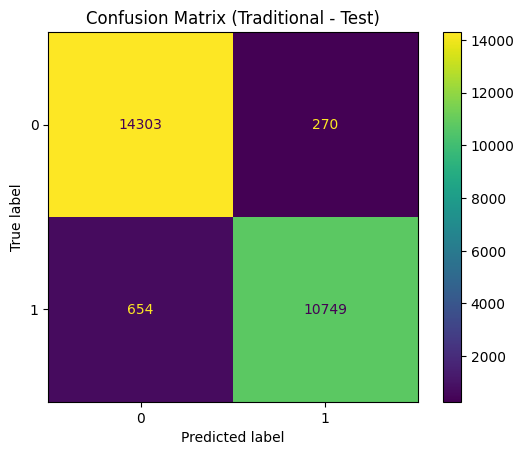

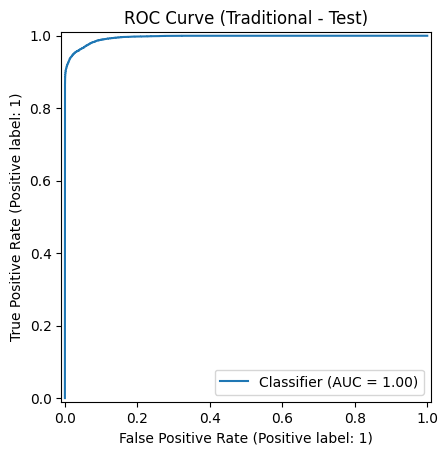

Saved: /root/test/score/src/outputs/traditional_test_predictions_reload.csv


In [33]:
# 4.1) Reload + run test (Traditional / Section 2)
ensure_xy_loaded()

OUT_DIR = globals().get("OUT_DIR", Path("./runs/default"))
ARTIFACTS_DIR = globals().get("ARTIFACTS_DIR", OUT_DIR / "artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

trad_path = ARTIFACTS_DIR / "best_pipeline.joblib"
if not trad_path.exists():
    raise FileNotFoundError(
        f"Không thấy {trad_path}. Bạn cần chạy Section 2 (train + save) ít nhất 1 lần để tạo file này."
    )

trad_pipe = joblib.load(trad_path)
print("Loaded traditional model:", trad_path)

if y_test is None:
    trad_pred = trad_pipe.predict(X_test)
    display(pd.Series(trad_pred).value_counts().rename("pred_counts"))
else:
    trad_pred = evaluate_on_test(trad_pipe, X_test, y_test, title="Traditional")

pred_df = pd.DataFrame({"y_pred": trad_pred})
pred_out = OUT_DIR / "traditional_test_predictions_reload.csv"
pred_df.to_csv(pred_out, index=False)
print("Saved:", pred_out)


## 4.2 Reload + run test (Deep Learning / Section 3)

DEVICE: cuda


Reloaded DL model: FTTransformer
Saved: /root/test/score/src/outputs/deep_learning_test_predictions_reload.csv
DL Reload — Test metrics:
  Accuracy : 0.9669695103172159
  Precision: 0.976761009132833
  Recall   : 0.9472945716039639
  F1       : 0.9618021547502449
  ROC-AUC  : 0.9953694343643137

Classification report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14573
           1       0.98      0.95      0.96     11403

    accuracy                           0.97     25976
   macro avg       0.97      0.96      0.97     25976
weighted avg       0.97      0.97      0.97     25976



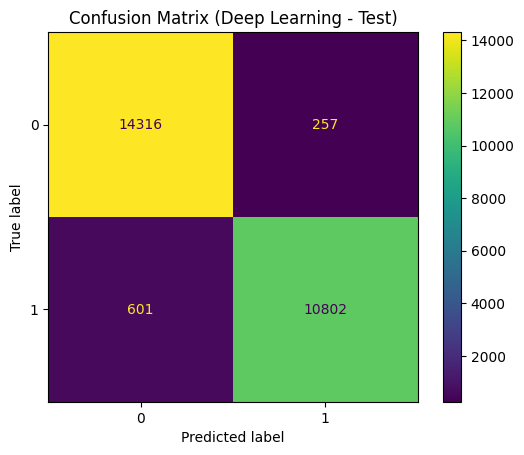

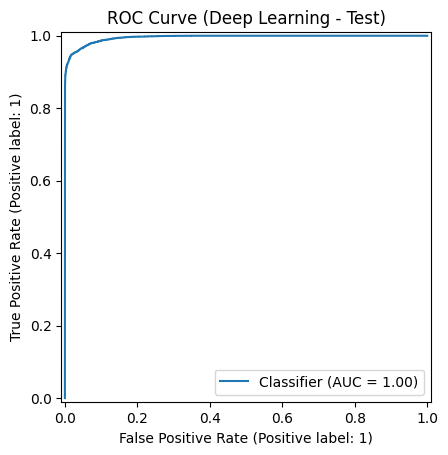

In [35]:
# 4.2) Reload + run test (Deep Learning / Section 3)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import joblib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

ensure_xy_loaded()

dl_dir = OUT_DIR / "deep_learning"
assert dl_dir.exists(), f"Không thấy folder DL: {dl_dir} (hãy chạy Section 3.9 để save)"

dl_feature_pipe_full = joblib.load(dl_dir / "dl_feature_pipe.joblib")
with open(dl_dir / "best_dl_meta.json", "r") as f:
    meta = json.load(f)

best_dl_name = meta["best_dl_name"]
threshold = meta.get("threshold", 0.5)

# ---- model defs (giống Section 3) ----
class MLP(nn.Module):
    def __init__(self, input_dim, hidden1=256, hidden2=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 1),
        )
    def forward(self, x):
        return self.net(x)

class MLP_BN_Dropout(nn.Module):
    def __init__(self, input_dim, hidden=256, dropout=0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.net(x)

class ResBlock(nn.Module):
    def __init__(self, dim, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.act = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(dim, dim)
    def forward(self, x):
        h = self.fc2(self.drop(self.act(self.fc1(x))))
        return x + h

class ResMLP(nn.Module):
    def __init__(self, input_dim, hidden=256, n_blocks=3, dropout=0.2):
        super().__init__()
        self.inp = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
        )
        self.blocks = nn.Sequential(*[ResBlock(hidden, dropout=dropout) for _ in range(n_blocks)])
        self.out = nn.Linear(hidden, 1)
    def forward(self, x):
        x = self.inp(x)
        x = self.blocks(x)
        return self.out(x)

class WideDeep(nn.Module):
    def __init__(self, input_dim, deep_hidden=256, dropout=0.25):
        super().__init__()
        self.wide = nn.Linear(input_dim, 1)
        self.deep = nn.Sequential(
            nn.Linear(input_dim, deep_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(deep_hidden, deep_hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(deep_hidden // 2, 1),
        )
    def forward(self, x):
        return self.wide(x) + self.deep(x)

class TabNetLite(nn.Module):
    def __init__(self, input_dim, hidden=256, n_steps=3, dropout=0.2):
        super().__init__()
        self.n_steps = n_steps
        self.gates = nn.ModuleList([
            nn.Sequential(nn.Linear(input_dim, input_dim), nn.Sigmoid())
            for _ in range(n_steps)
        ])
        self.mlps = nn.ModuleList([
            nn.Sequential(
                nn.Linear(input_dim, hidden),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden, hidden // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden // 2, 1),
            )
            for _ in range(n_steps)
        ])

    def forward(self, x):
        out = 0.0
        for gate, mlp in zip(self.gates, self.mlps):
            m = gate(x)
            out = out + mlp(x * m)
        return out / self.n_steps

class FTTransformer(nn.Module):
    def __init__(self, n_features, d_model=96, n_heads=8, n_layers=3, dropout=0.1, ff_mult=4):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(n_features, d_model) * 0.02)
        self.bias   = nn.Parameter(torch.zeros(n_features, d_model))
        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * ff_mult,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Linear(d_model, 1))

    def forward(self, x):
        tok = x.unsqueeze(-1) * self.weight.unsqueeze(0) + self.bias.unsqueeze(0)
        cls = self.cls.expand(x.size(0), -1, -1)
        h = torch.cat([cls, tok], dim=1)
        h = self.encoder(h)
        return self.head(h[:, 0, :])

def build_dl_model(name, input_dim):
    if name == "MLP":
        return MLP(input_dim)
    if name == "MLP_BN_Dropout":
        return MLP_BN_Dropout(input_dim)
    if name == "ResMLP":
        return ResMLP(input_dim, hidden=256, n_blocks=3, dropout=0.2)
    if name == "WideDeep":
        return WideDeep(input_dim, deep_hidden=256, dropout=0.25)
    if name == "TabNetLite":
        return TabNetLite(input_dim, hidden=256, n_steps=3, dropout=0.2)
    if name == "FTTransformer":
        return FTTransformer(input_dim, d_model=96, n_heads=8, n_layers=3, dropout=0.1, ff_mult=4)
    raise ValueError(f"Unknown DL model name: {name}")

# ---- data ----
X_test_dl = dl_feature_pipe_full.transform(X_test).astype(np.float32)
has_y_test = y_test is not None
y_test_np = y_test.to_numpy().astype(int) if has_y_test else np.zeros(X_test_dl.shape[0], dtype=int)

class TabDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).view(-1, 1).float()
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

test_loader = DataLoader(TabDataset(X_test_dl, y_test_np), batch_size=2048, shuffle=False)

@torch.no_grad()
def predict_logits(model, loader, device=DEVICE):
    model.eval()
    logits_all = []
    y_all = []
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb).detach().cpu().numpy().reshape(-1)
        logits_all.append(logits)
        y_all.append(yb.numpy().reshape(-1))
    return np.concatenate(y_all).astype(int), np.concatenate(logits_all)

# ---- load weights ----
model = build_dl_model(best_dl_name, X_test_dl.shape[1]).to(DEVICE)
state = torch.load(dl_dir / "best_dl_model.pt", map_location=DEVICE)
model.load_state_dict(state)

y_true, logits = predict_logits(model, test_loader)
probs = 1 / (1 + np.exp(-logits))
preds = (probs >= threshold).astype(int)

print("Reloaded DL model:", best_dl_name)
pred_df = pd.DataFrame({"y_pred": preds, "y_prob": probs})
pred_out = OUT_DIR / "deep_learning_test_predictions_reload.csv"
pred_df.to_csv(pred_out, index=False)
print("Saved:", pred_out)

if has_y_test:
    print("DL Reload — Test metrics:")
    print("  Accuracy :", accuracy_score(y_true, preds))
    print("  Precision:", precision_score(y_true, preds))
    print("  Recall   :", recall_score(y_true, preds))
    print("  F1       :", f1_score(y_true, preds))
    print("  ROC-AUC  :", roc_auc_score(y_true, probs))

    print("\nClassification report:")
    print(classification_report(y_true, preds))

    cm = confusion_matrix(y_true, preds)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot()
    plt.title("Confusion Matrix (Deep Learning - Test)")
    plt.show()

    RocCurveDisplay.from_predictions(y_true, probs)
    plt.title("ROC Curve (Deep Learning - Test)")
    plt.show()
else:
    print("Test set không có ground-truth (y_test=None). Chỉ lưu y_pred/y_prob.")

In [ ]:
# 5.Summary
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

ensure_xy_loaded()

summary_rows = []

# --- Traditional (Section 4.1) ---
trad_pred_path = OUT_DIR / "traditional_test_predictions_reload.csv"
if y_test is not None and trad_pred_path.exists():
    trad_pred = pd.read_csv(trad_pred_path)["y_pred"].to_numpy()

    # Lấy score nếu có để tính ROC-AUC chuẩn
    trad_auc = float("nan")
    try:
        trad_pipe = joblib.load(ARTIFACTS_DIR / "best_pipeline.joblib")
        if hasattr(trad_pipe, "predict_proba"):
            trad_score = trad_pipe.predict_proba(X_test)[:, 1]
            trad_auc = roc_auc_score(y_test, trad_score)
        elif hasattr(trad_pipe, "decision_function"):
            trad_score = trad_pipe.decision_function(X_test)
            trad_auc = roc_auc_score(y_test, trad_score)
    except Exception:
        pass

    summary_rows.append({
        "model_group": "Traditional",
        "accuracy": accuracy_score(y_test, trad_pred),
        "precision": precision_score(y_test, trad_pred),
        "recall": recall_score(y_test, trad_pred),
        "f1": f1_score(y_test, trad_pred),
        "roc_auc": trad_auc,
    })

# --- Deep Learning (Section 4.2) ---
dl_pred_path = OUT_DIR / "deep_learning_test_predictions_reload.csv"
if y_test is not None and dl_pred_path.exists():
    dl_df = pd.read_csv(dl_pred_path)
    dl_pred = dl_df["y_pred"].to_numpy()
    dl_prob = dl_df["y_prob"].to_numpy() if "y_prob" in dl_df.columns else None

    summary_rows.append({
        "model_group": "Deep Learning",
        "accuracy": accuracy_score(y_test, dl_pred),
        "precision": precision_score(y_test, dl_pred),
        "recall": recall_score(y_test, dl_pred),
        "f1": f1_score(y_test, dl_pred),
        "roc_auc": roc_auc_score(y_test, dl_prob) if dl_prob is not None else float("nan"),
    })

if len(summary_rows) == 0:
    print("Chưa có đủ file dự đoán để tổng hợp. Hãy chạy lại cell 4.1 và 4.2 trước.")
else:
    summary_df = pd.DataFrame(summary_rows).sort_values(["f1", "roc_auc"], ascending=False).reset_index(drop=True)
    summary_df["rank"] = summary_df.index + 1
    cols = ["rank", "model_group", "accuracy", "precision", "recall", "f1", "roc_auc"]
    display(summary_df[cols].round(6))

    best = summary_df.iloc[0]
    print(f"Winner (ưu tiên F1, tie-break ROC-AUC): {best['model_group']}")

,rank,model_group,accuracy,precision,recall,f1,roc_auc
0,1,4.2 Deep Learning,0.966970,0.976761,0.947295,0.961802,0.995369
1,2,4.1 Traditional,0.964429,0.975497,0.942647,0.958790,0.995552


Winner (ưu tiên F1, tie-break ROC-AUC): 4.2 Deep Learning
